<a href="https://colab.research.google.com/github/LiYuan199701/TimeSeries/blob/Bayesian-single-perceptron-TS/Grid_Search_Bernstein_basis_BNAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load R complier and dCovTS packages

In [1]:
%%bash
apt-get update
apt-get install -y r-base
apt-get install -y libgsl-dev

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,289 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,637 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,205 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,867 kB]
G

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
%load_ext rpy2.ipython

In [3]:
%%R
install.packages("dCovTS", repos="https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘RcppArmadillo’, ‘iterators’, ‘zigg’, ‘RcppParallel’, ‘Rnanoflann’, ‘BH’, ‘dcov’, ‘doParallel’, ‘foreach’, ‘Rfast’, ‘Rfast2’

trying URL 'https://cloud.r-project.org/src/contrib/RcppArmadillo_15.2.3-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/zigg_0.0.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RcppParallel_5.1.11-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/Rnanoflann_0.0.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/BH_1.90.0-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/dcov_0.1.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/doParallel_1.0.17.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/foreach_1.5.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/Rfast_2.1.5.2.tar.gz'


In [4]:
%%R
install.packages("energy")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘gsl’

trying URL 'https://cran.rstudio.com/src/contrib/gsl_2.1-9.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/energy_1.7-12.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpMyhaEp/downloaded_packages’


In [5]:
%%bash
R -e "library(dCovTS);library(energy)"


R version 4.5.2 (2025-10-31) -- "[Not] Part in a Rumble"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> library(dCovTS);library(energy)
> 



dCovTS: 1.4
               _ _ _ _                            _ _ _ _ _    _ _ _ _ _
       _      /   _ _ _\                         |_ _   _ _|  |  _ _ _ _/
      | |    /  /                                    | |      | |
 _ _ _| |    | |           _ _ _ _    _      _       | |      | |_ _ _ _ 
|  _ _  |    | |          |  _ _  |  \ \    / /      | |      |_ _ _ _  |
| |   | |    | |          | |   | |   \ \  / /       | |              | |
| |_ _| |_   \  \ _ _ _   | |_ _| |    \ \/ /        | |       _ _ _ _| |
|_ _ _ _ _|   \_ _ _ _ /  |_ _ _ _|     \__/         |_|      /_ _ _ _ _|


# Make bridge between R and Python

In [6]:
pip install rpy2

In [7]:
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr

numpy2ri.activate()

dCovTS = importr("dCovTS")

# Load Python packages

In [8]:
# ===============================
# Bayesian single-perceptron NAR(d)
# with recency-decaying prior means
# ===============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from joblib import Parallel, delayed
import multiprocessing

%matplotlib inline
# Set inline backend and resolution
%config InlineBackend.figure_format = 'retina'  # For Retina displays
plt.rcParams['figure.dpi'] = 150  # Set dpi to 200 for high resolution

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate the Bernstein Polynomial Approximation

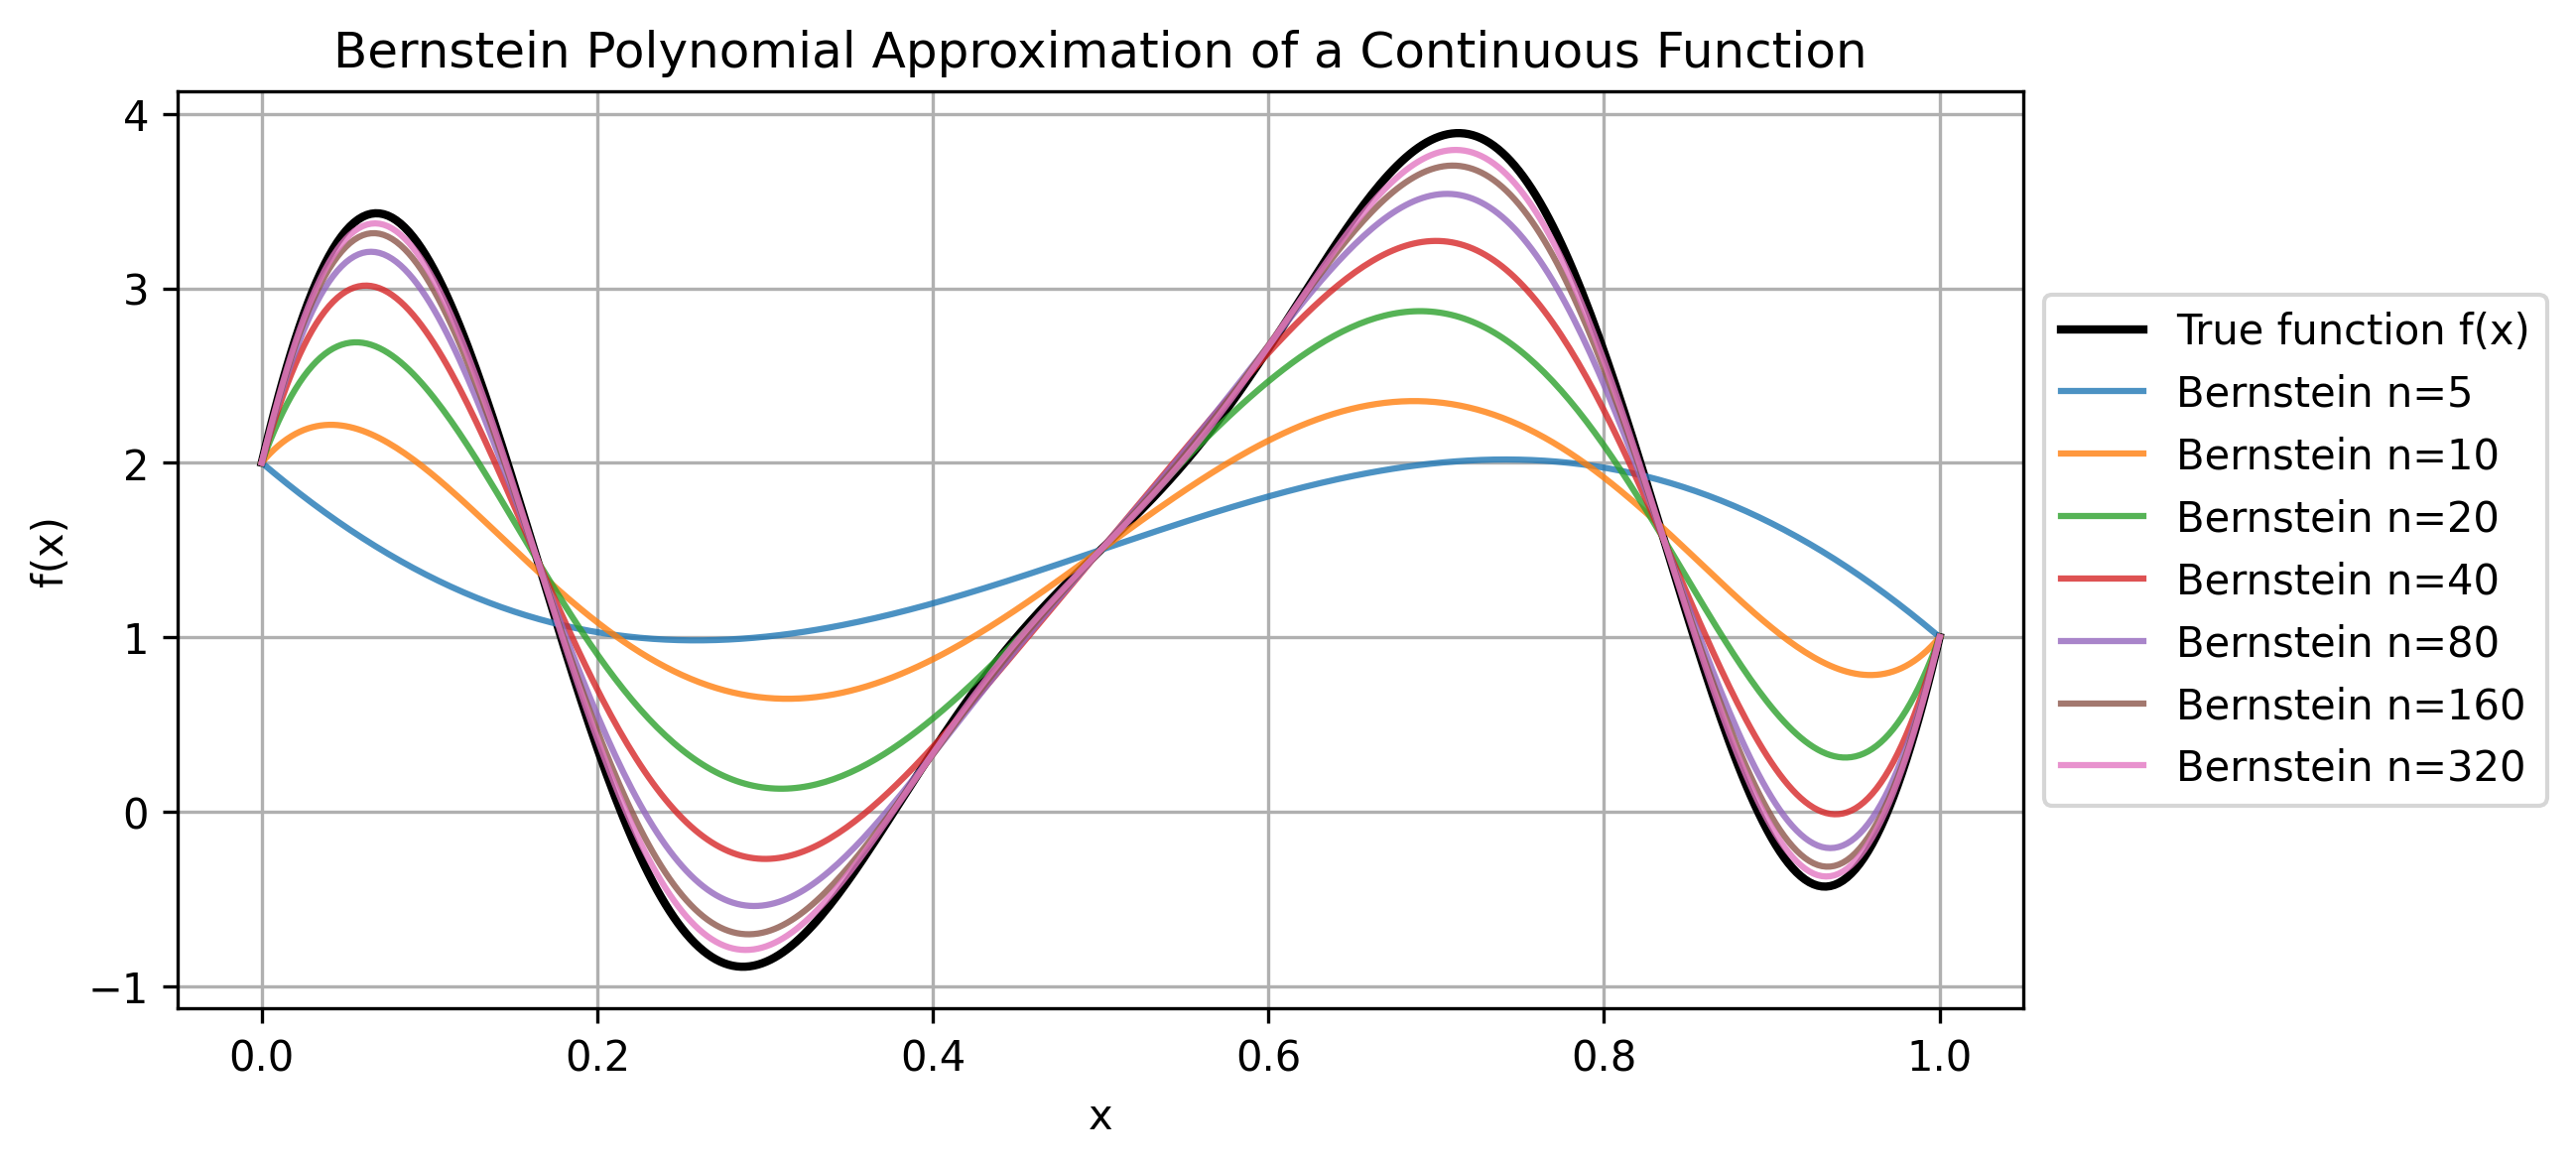

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
import math

# ============================================================
# Bernstein basis function (provided by you)
# ============================================================
def bernstein_basis_1d(z, degree):
    """
    z: shape (N,)
    degree: Bernstein degree n

    Returns:
        B: shape (N, degree+1)
        Each column k is B_{k,n}(z)
    """
    z = np.asarray(z).reshape(-1)
    N = len(z)
    B = np.zeros((N, degree+1))

    for k in range(degree+1):
        B[:, k] = comb(degree, k) * (z**k) * ((1 - z)**(degree - k))

    return B


# ============================================================
# 1. Simulated continuous function on [0,1]
# ============================================================
def f(x):
    return 3*x + 3*np.sin(4*np.pi*x) + 2*np.cos(5*np.pi*x)

# grid on [0,1]
x = np.linspace(0, 1, 400)
fx = f(x)

# ============================================================
# 2. Bernstein approximation for degree n
# ============================================================
def bernstein_approx(f, x, degree):
    """
    Compute Bernstein approximation B_n(f)(x)
    """
    n = degree

    # f(k/n) for k=0,...,n
    sample_points = np.linspace(0, 1, n+1)
    f_samples = f(sample_points)    # shape (n+1,)

    # construct Bernstein basis for each x
    B = bernstein_basis_1d(x, n)    # shape (len(x), n+1)

    # B_n(f)(x) = sum_k f(k/n) * B_{k,n}(x)
    return B @ f_samples


# ============================================================
# 3. Plot true function and approximations
# ============================================================
degrees = [5, 10, 20, 40, 80, 160, 320]

plt.figure(figsize=(8, 4))
plt.plot(x, fx, 'k-', linewidth=2, label="True function f(x)")

for n in degrees:
    approx = bernstein_approx(f, x, n)
    plt.plot(x, approx, label=f"Bernstein n={n}", alpha=0.8)

plt.title("Bernstein Polynomial Approximation of a Continuous Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()

# Define the simulation models

In [10]:
# ============================================
#   MODEL 1
# ============================================
def simulate_model1(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        if X[t-1] <= 0:
            X[t] = 0.1 * X[t-1] + eps
        else:
            X[t] = 0.8 * X[t-1] + eps
    return X

# ============================================
#   MODEL 2
# ============================================
def simulate_model2(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[:3] = np.random.randn(3)

    for t in range(3, T):
        eps = np.random.randn() * sigma_eps
        if X[t-1] <= 0:
            X[t] = 0.5*X[t-1] + 0.2*X[t-2] + 0.1*X[t-3] + eps
        else:
            X[t] = 0.8*X[t-1] + eps
    return X

# ============================================
#   MODEL 3
# ============================================
def simulate_model3(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn()
        if X[t-1] <= 0:
            X[t] = 0.1 * X[t-1] + 0.5*np.exp(-X[t-1]**2) * eps
        else:
            X[t] = 0.8 * X[t-1] + 0.5*np.exp(-X[t-1]**2) * eps
    return X

# ============================================
#   MODEL 4
# ============================================
def simulate_model4(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        X[t] = 0.2 + np.log(0.5 + np.abs(X[t-1])) + eps
    return X

# ============================================
#   MODEL 5
# ============================================
def simulate_model5(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn() + 1.0

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        X[t] = 2 * np.log(X[t-1]**2 + 1e-6) + eps
    return X

# ============================================
#   MODEL 6
# ============================================
def simulate_model6(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[0] = np.random.randn()

    for t in range(1, T):
        eps = np.random.randn() * sigma_eps
        X[t] = np.log(10 + 5 * np.exp(0.9 * X[t-1])) + eps
    return X

# ============================================
#   MODEL 7
# ============================================
def simulate_model7(T=2000, sigma_eps=1.0):
    X = np.zeros(T)
    X[:3] = np.random.randn(3)

    for t in range(3, T):
        eps = np.random.randn() * sigma_eps
        term = (4*np.exp(0.9*X[t-2]) +
                5*np.exp(0.9*X[t-1]) +
                6*np.exp(0.9*X[t-3]))
        X[t] = np.log(term) + eps
    return X

# =====================================================
# Unified wrapper
# =====================================================
def simulate(model_id, T=2000, sigma_eps=1.0):
    if model_id == 1: return simulate_model1(T, sigma_eps)
    if model_id == 2: return simulate_model2(T, sigma_eps)
    if model_id == 3: return simulate_model3(T, sigma_eps)
    if model_id == 4: return simulate_model4(T, sigma_eps)
    if model_id == 5: return simulate_model5(T, sigma_eps)
    if model_id == 6: return simulate_model6(T, sigma_eps)
    if model_id == 7: return simulate_model7(T, sigma_eps)
    raise ValueError("Model ID must be 1–7")

# Generate simulation data

x_min: -3.22108962580138
x_max: 3.7164585876811453
x_mean: 0.4132982858412381
x_std: 1.1321191491951828


Text(0.5, 1.0, 'Model 4 Time Series')

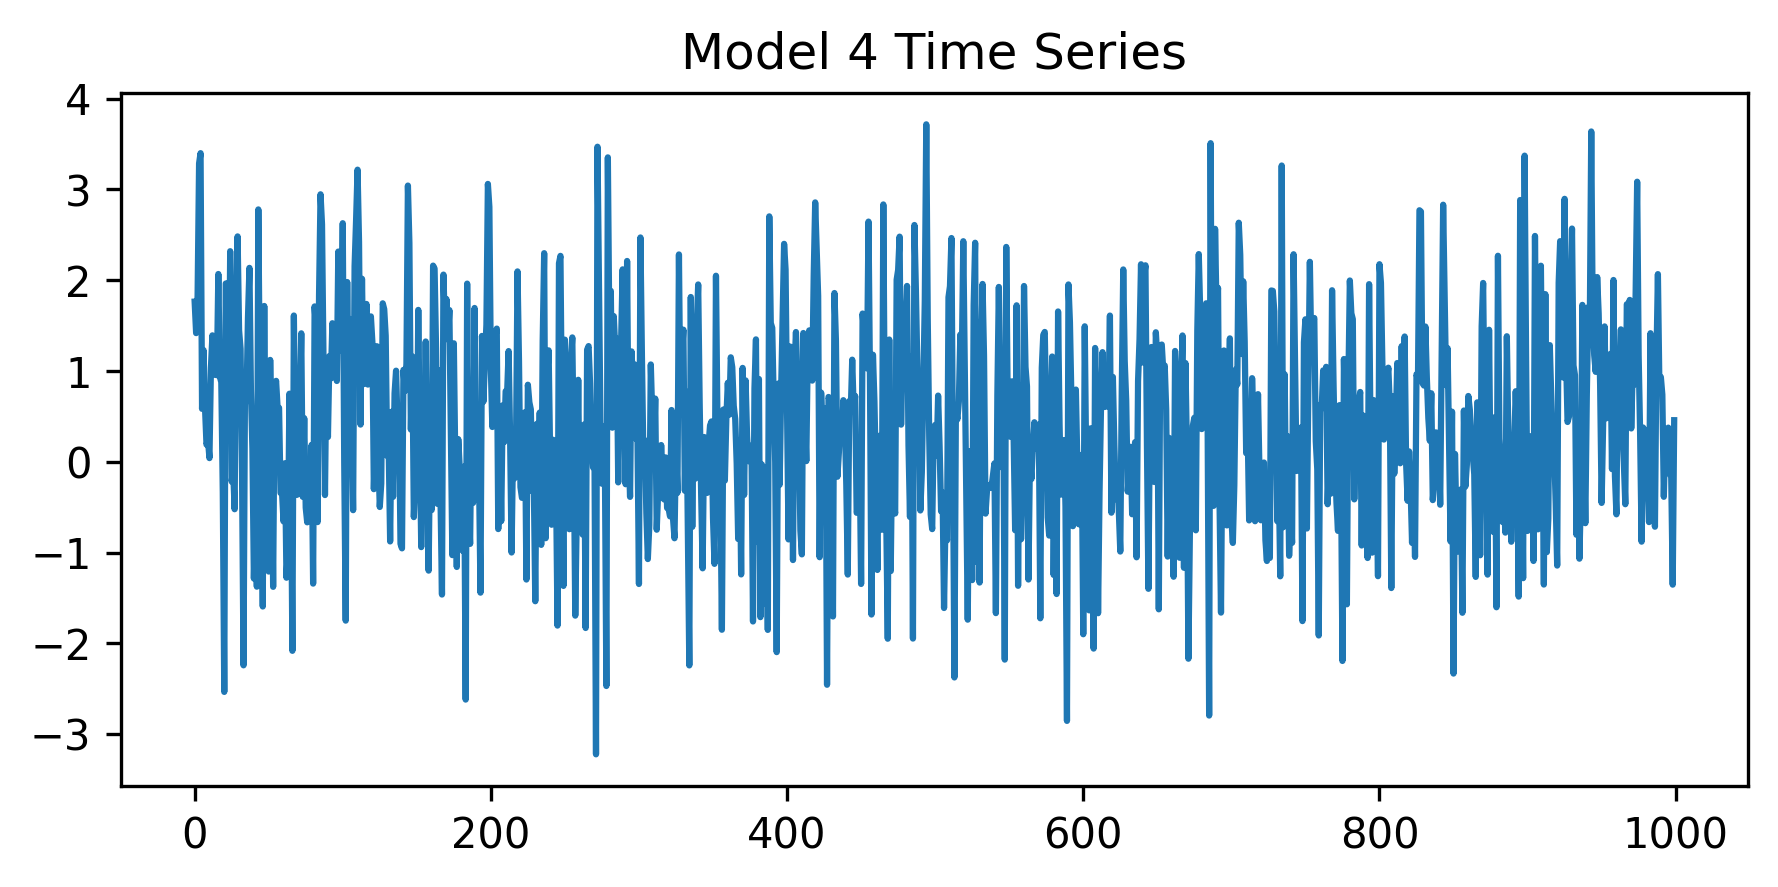

In [122]:
# Set a random seed
np.random.seed(0)
# Set the number of samples
T = 1000
id = 4
x = simulate(model_id=id, T = T)
# create the summary statistics of x time series including min and max
x_min = np.min(x)
x_max = np.max(x)
x_mean = np.mean(x)
x_std = np.std(x)
# print the summary statistics
print("x_min:", x_min)
print("x_max:", x_max)
print("x_mean:", x_mean)
print("x_std:", x_std)

# plot this time series
plt.figure(figsize=(7,3))
plt.plot(x)
# change title name by model id
plt.title(f"Model {id} Time Series")

# Define functions to form lag and build nonlinear basis

In [123]:
import numpy as np
import torch

# ----------------------------------------------------------
# 1. Scaling function
# ----------------------------------------------------------
def scale_to_unit_interval(X, do_scale=True):
    """
    Scale time series X to [-1, 1] ONLY IF:
        (1) do_scale=True, AND
        (2) X is not already in [-1, 1].

    Returns:
        X_scaled, scale_factor c
    """
    X = np.asarray(X).reshape(-1)

    # If user disables scaling
    if not do_scale:
        return X, 1.0

    X_min = np.min(X)
    X_max = np.max(X)

    # If the entire series is already within [-1, 1], don't scale
    if X_min >= -1.0 and X_max <= 1.0:
        return X, 1.0

    # Otherwise compute scale c
    c = max(abs(X_min), abs(X_max))
    if c < 1e-12:
        c = 1.0   # avoid divide-by-zero for constant series

    return X / c, c



# ----------------------------------------------------------
# 2. Build lag matrix
# ----------------------------------------------------------
def build_lag_matrix(x, d):
    """
    x: 1-D array (N,)
    d: number of lags

    Returns:
        X_lag: shape (N-d, d)
        y:     shape (N-d,)
    """
    x = np.asarray(x).reshape(-1)
    N = len(x)

    X_lag = np.zeros((N - d, d))
    for k in range(1, d + 1):
        X_lag[:, k - 1] = x[d - k : N - k]

    y = x[d:]
    return X_lag, y

# ----------------------------------------------------------
# A. Bernstein basis for a single normalized variable z∈[0,1]
# ----------------------------------------------------------
import numpy as np
from math import comb

def bernstein_basis_1d(z, degree):
    """
    z: shape (N,)
    degree: Bernstein degree n

    Returns:
        B: shape (N, degree+1)
        Each column k is B_{k,n}(z)
    """
    z = np.asarray(z).reshape(-1)
    N = len(z)
    B = np.zeros((N, degree+1))

    for k in range(degree+1):
        B[:, k] = comb(degree, k) * (z**k) * ((1 - z)**(degree - k))

    return B

# ----------------------------------------------------------
# B. Build full Bernstein basis for AR(d) lag matrix
# ----------------------------------------------------------
def build_bernstein_full_basis(X_lag, degree=5):
    """
    X_lag: shape (N, d) lag matrix
    For each lag column, apply Bernstein basis separately.
    """
    X_lag = np.asarray(X_lag)
    N, d = X_lag.shape
    basis_list = []

    # normalize each lag independently into [0,1]
    # Bernstein requires z ∈ [0,1]
    X_min = X_lag.min(axis=0)
    X_max = X_lag.max(axis=0)
    X_range = X_max - X_min + 1e-8
    Z = (X_lag - X_min) / X_range

    for j in range(d):
        Bj = bernstein_basis_1d(Z[:, j], degree)
        basis_list.append(Bj)

    return np.concatenate(basis_list, axis=1)

# Scale Data

Text(0.5, 1.0, 'Scaled Model 4 Time Series')

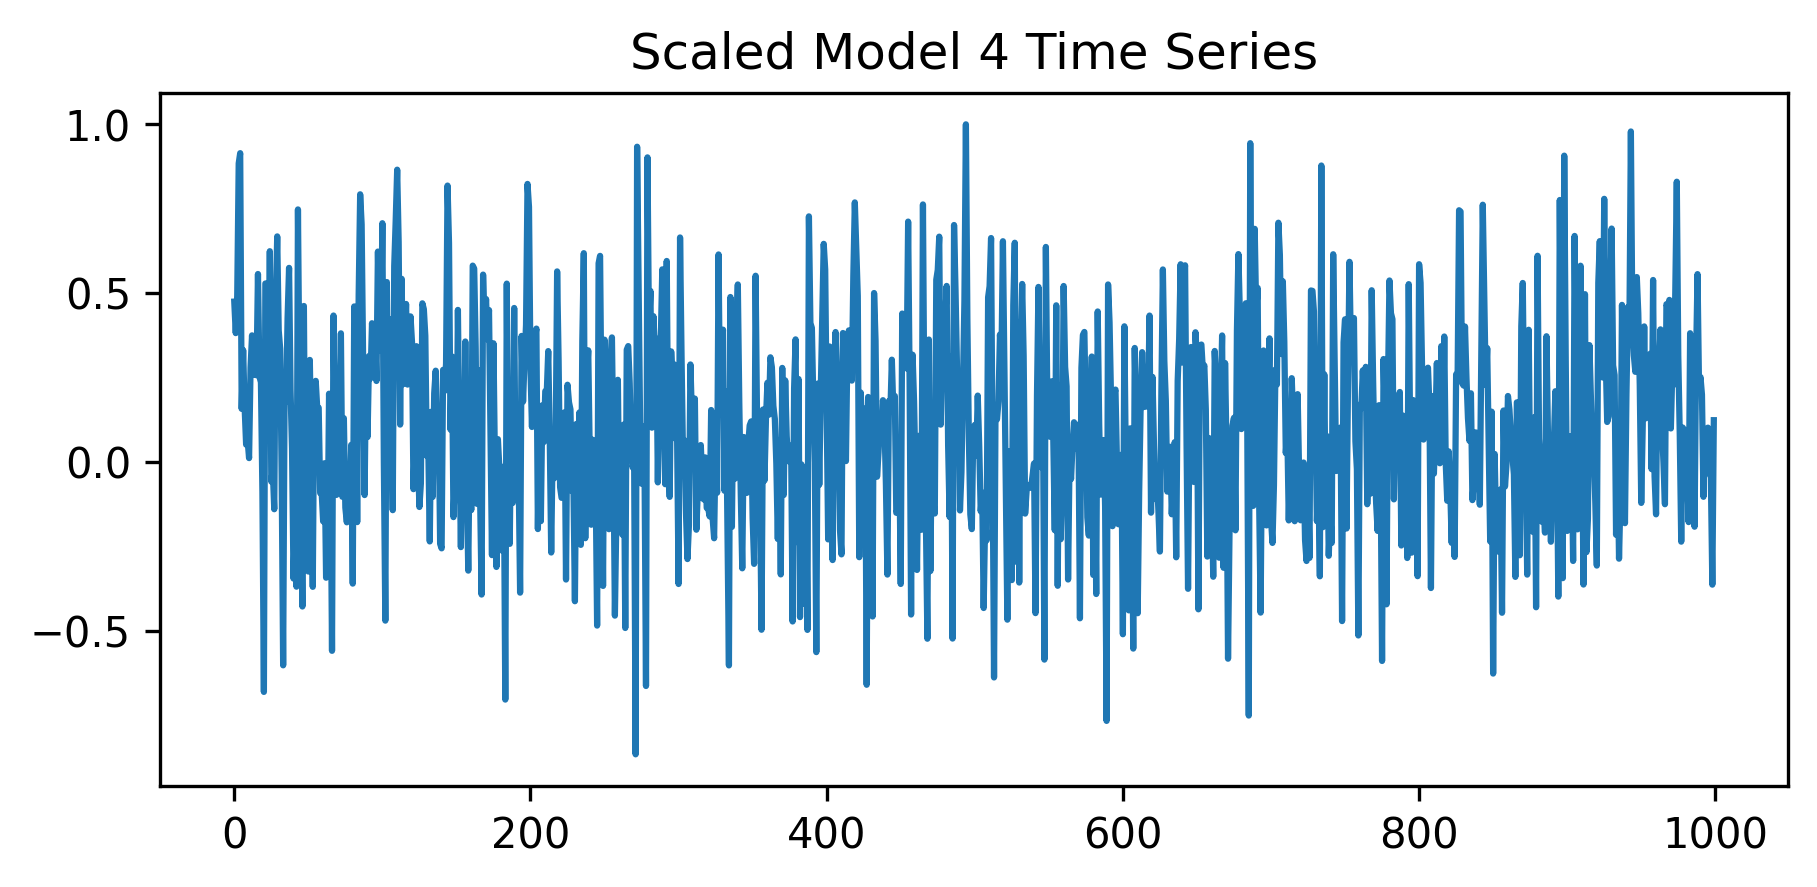

In [124]:
x_scaled, c = scale_to_unit_interval(x, True)
# plot this time series
plt.figure(figsize=(7,3))
plt.plot(x_scaled)
# change title name by model id
plt.title(f"Scaled Model {id} Time Series")

# Define ADCF function to select the lag d by dCovTS package

In [125]:
def adcf_from_python(x, max_lag=20):
    """
    Compute ADCF using dCovTS from Python (Google Colab compatible).
    """
    x = np.asarray(x).astype(float)
    rx = ro.FloatVector(x)

    adcf = dCovTS.ADCF(rx, MaxLag=max_lag)
    adcf = np.array(adcf)

    return adcf

# Auto-Distance Correlation Function

In [126]:
adcf_from_python(x_scaled)

array([[1.        , 0.28929011, 0.07436773, 0.04992753, 0.05014905,
        0.05324468, 0.04286275, 0.0984252 , 0.06928182, 0.04752554,
        0.05621073, 0.04289846, 0.05072969, 0.07954443, 0.07066653,
        0.05221869, 0.06024645, 0.06946744, 0.05602472, 0.04607144,
        0.04478052]])

$ADCF
   lag 0     lag 1      lag 2      lag 3      lag 4      lag 5      lag 6
       1 0.2892901 0.07436773 0.04992753 0.05014905 0.05324468 0.04286275
       lag 7      lag 8      lag 9     lag 10     lag 11     lag 12     lag 13
   0.0984252 0.06928182 0.04752554 0.05621073 0.04289846 0.05072969 0.07954443
       lag 14     lag 15     lag 16     lag 17     lag 18     lag 19     lag 20
   0.07066653 0.05221869 0.06024645 0.06946744 0.05602472 0.04607144 0.04478052
       lag 21     lag 22     lag 23     lag 24     lag 25     lag 26     lag 27
   0.04657057 0.06198858 0.04268446 0.05618955 0.05482233 0.08602745 0.06522621
       lag 28     lag 29     lag 30     lag 31     lag 32     lag 33    lag 34
   0.05419676 0.04779629 0.05371301 0.05954638 0.05456668 0.04212421 0.0490464
       lag 35    lag 36     lag 37     lag 38     lag 39     lag 40
   0.03909279 0.0608629 0.04046239 0.05225664 0.05650458 0.06109279

$bootMethod
[1] "Wild Bootstrap"

$critical.values
[1] 0.08229066



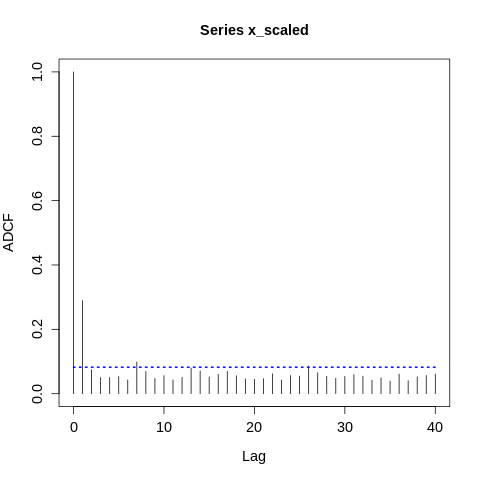

In [127]:
%%R -i x_scaled
library(dCovTS)
options(repr.plot.width=8, repr.plot.height=4)
ADCFplot(x_scaled, MaxLag=40, alpha=0.05)

# Partial distance correlation

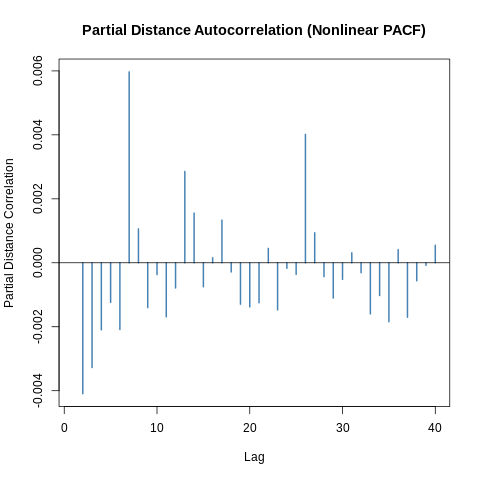

In [128]:
%%R -i x_scaled

library(energy)

options(repr.plot.width=8, repr.plot.height=4)

x <- as.numeric(x_scaled)
T <- length(x)
MaxLag <- 40

pdcor_vals <- rep(NA, MaxLag)

for (k in 2:MaxLag) {

  # Align series
  yt  <- x[(k+1):T]
  xk  <- x[1:(T-k)]

  # Conditioning matrix Z = (X_{t-1}, ..., X_{t-k+1})
  Z <- sapply(1:(k-1), function(j)
    x[(k-j+1):(T-j)]
  )

  # Partial distance correlation
  pdcor_vals[k] <- pdcor(xk, yt, Z)
}

# Plot (PACF-style)
plot(
  1:MaxLag, pdcor_vals,
  type = "h",
  lwd = 2,
  col = "steelblue",
  xlab = "Lag",
  ylab = "Partial Distance Correlation",
  main = "Partial Distance Autocorrelation (Nonlinear PACF)"
)

abline(h = 0, col = "black")

# Define the function to pick up the highest value of ADCF

In [129]:
def select_lag_d(adcf_vals, threshold=0.05):
    sig_lags = np.where(adcf_vals > threshold)[0] + 1
    return int(sig_lags.max()) if len(sig_lags) > 0 else 1

adcf_vals = adcf_from_python(x_scaled, max_lag=40)
d_selected = select_lag_d(adcf_vals)
print("Selected lag order:", d_selected)

Selected lag order: 1


# Define BNAR_FullCov Model

In [130]:
# ============================================
# Module 2: model_block.py
# BNAR-FullCov with Independent Gaussian Prior
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class BNAR_FullCov(nn.Module):

    def __init__(self, d, activation="tanh", prior_std=1.0, sigma_floor = 0.9):
        """
        d: number of basis-expanded input features
        activation: "tanh", "identity", "relu", "elu", "softplus"
        prior_std: std of independent Gaussian prior p(w) = N(0, prior_std^2 I)
        """
        super().__init__()
        self.d = d
        self.prior_std = prior_std
        self.activation_name = activation
        self.activation = self.get_activation(activation)
        self.sigma_floor = sigma_floor

        # variational mean
        self.m_w = nn.Parameter(torch.randn(d) * 0.1)

        # diagonal log std for Lq diagonal
        self.log_diag_Lq = nn.Parameter(torch.full((d,), math.log(0.1)))

        # strictly lower triangular unconstrained parameters
        tril_idx = torch.tril_indices(d, d, offset=-1)
        self.Lq_offdiag = nn.Parameter(torch.zeros(tril_idx.shape[1]))

        # bias term
        self.b = nn.Parameter(torch.tensor(0.0))

        # observation noise (Gaussian)
        self.log_sigma_eps = nn.Parameter(torch.tensor(math.log(0.1)))

    # ------------------------------------------------------------
    def get_activation(self, name):
        if name == "tanh":
            return torch.tanh
        elif name == "identity":
            return lambda x: x
        elif name == "relu":
            return F.relu
        elif name == "elu":
            return F.elu
        elif name == "softplus":
            return F.softplus
        else:
            raise ValueError(f"Unknown activation: {name}")

    # ------------------------------------------------------------
    def get_Lq(self, device):
        """Build lower triangular matrix L_q."""
        L_q = torch.zeros(self.d, self.d, device=device)
        tril_idx = torch.tril_indices(self.d, self.d, offset=-1)

        # fill strictly lower elements
        L_q[tril_idx[0], tril_idx[1]] = self.Lq_offdiag

        # add positive diagonal
        L_q = L_q + torch.diag(torch.exp(self.log_diag_Lq))
        return L_q

    # ------------------------------------------------------------
    def kl_gaussian_full(self, mu_q, L_q):
        """
        KL( q(w) || p(w) )
        Prior: p(w) = N(0, prior_std^2 I)
        q(w) = N(mu_q, L_q L_q^T)
        """
        d = mu_q.shape[0]
        Sigma_q = L_q @ L_q.T

        # prior precision: 1 / prior_std^2
        prior_var = self.prior_std ** 2
        Sigma_p_inv = torch.eye(d, device=mu_q.device) / prior_var

        trace_term = torch.trace(Sigma_p_inv @ Sigma_q)
        quad_term = (mu_q @ Sigma_p_inv @ mu_q)

        # log determinants
        log_det_q = 2 * torch.sum(torch.log(torch.diag(L_q)))
        log_det_p = d * math.log(prior_var)

        kl = 0.5 * (trace_term + quad_term - d + log_det_p - log_det_q)
        return kl

    # ------------------------------------------------------------
    def forward(self, X, sample=True, kl_weight=1.0):
        """
        X: (n_samples, d) tensor
        """
        device = X.device
        L_q = self.get_Lq(device)

        if sample and self.training:
            eps = torch.randn(self.d, device=device)
            w = self.m_w + L_q @ eps
        else:
            w = self.m_w

        lin = (X @ w).unsqueeze(1) + self.b
        yhat = self.activation(lin)

        sigma_eps = F.softplus(self.log_sigma_eps) + self.sigma_floor
        kl = self.kl_gaussian_full(self.m_w, L_q)

        return yhat, sigma_eps, kl_weight * kl

    # ------------------------------------------------------------
    def negative_elbo(self, X, y, kl_weight=1.0):
        yhat, sigma_eps, kl_term = self.forward(X, sample=True, kl_weight=kl_weight)

        n = X.shape[0]
        log_likelihood = (
            -0.5 * n * torch.log(2 * torch.tensor(math.pi) * sigma_eps**2)
            - 0.5 * torch.sum((y - yhat)**2) / (sigma_eps**2)
        )

        return -log_likelihood + kl_term, yhat

# Define R function to run UnivTest

In [131]:
%%writefile univtest_wrapper.R
# univtest_wrapper.R
library(dCovTS)

args <- commandArgs(trailingOnly = TRUE)
residual_file <- args[1]
output_file   <- args[2]

# Load residuals
res <- scan(residual_file)

# Bandwidth choice (recommended in dCovTS)
n <- length(res)
c <- 3
lambda <- 0.1
p <- ceiling(c * n^lambda)

# UnivTest using distance correlation
test <- UnivTest(
  res,
  type = "truncated",
  testType = "correlation",
  p = p,
  b = 500,
  parallel = FALSE
)

# Save results
out <- data.frame(
  statistic = test$statistic,
  p_value   = test$p.value
)
write.csv(out, output_file, row.names = FALSE)

Overwriting univtest_wrapper.R


# Define Python UnivTest function with R above

In [132]:
import subprocess
import tempfile
import os

def run_univtest(residuals):
    """
    Run dCovTS::UnivTest on residuals via R.
    Returns p-value.
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        res_file = os.path.join(tmpdir, "res.txt")
        out_file = os.path.join(tmpdir, "out.csv")

        np.savetxt(res_file, residuals)

        cmd = [
            "Rscript",
            "univtest_wrapper.R",
            res_file,
            out_file
        ]
        subprocess.run(cmd, check=True)

        df = pd.read_csv(out_file)
        return df["p_value"].iloc[0]

# Define Train_Evaluate function

In [133]:
import numpy as np
import pandas as pd
import torch
from statsmodels.stats.diagnostic import acorr_ljungbox

def train_and_evaluate_bnar(
    x_scaled,
    build_lag_matrix,
    build_bernstein_full_basis,
    model_class,
    d,
    degree,
    device,
    n_epochs=3000,
    lr=1e-3,
    kl_weight=0.1,
    ljung_lag=20,
    activation="tanh",
    prior_std=1.0,
    sigma_floor=1e-6,
):
    """
    Train one Bernstein-BNAR model and return metrics.
    """

    # -------------------------
    # Build lagged design
    # -------------------------
    X_lag, y = build_lag_matrix(x_scaled, d)

    X_basis = build_bernstein_full_basis(X_lag, degree=degree)

    N = len(y)
    n_train = int(0.7 * N)
    n_val   = int(0.15 * N)

    idx_tr = slice(0, n_train)
    idx_va = slice(n_train, n_train + n_val)
    idx_te = slice(n_train + n_val, N)

    Xtr, ytr = X_basis[idx_tr], y[idx_tr]
    Xva, yva = X_basis[idx_va], y[idx_va]
    Xte, yte = X_basis[idx_te], y[idx_te]

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).unsqueeze(1)
    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
    yva_t = torch.tensor(yva, dtype=torch.float32, device=device).unsqueeze(1)
    Xte_t = torch.tensor(Xte, dtype=torch.float32, device=device)
    yte_t = torch.tensor(yte, dtype=torch.float32, device=device).unsqueeze(1)

    # -------------------------
    # Model
    # -------------------------
    model = model_class(
    d=Xtr.shape[1],
    activation=activation,
    prior_std=prior_std,
    sigma_floor=sigma_floor).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        nelbo, _ = model.negative_elbo(Xtr_t, ytr_t, kl_weight=kl_weight)
        nelbo.backward()
        optimizer.step()

    # -------------------------
    # Evaluation
    # -------------------------
    model.eval()
    with torch.no_grad():
        ytr_hat, sigma_tr, _ = model.forward(Xtr_t, sample=False)
        yva_hat, sigma_va, _ = model.forward(Xva_t, sample=False)
        yte_hat, sigma_te, _ = model.forward(Xte_t, sample=False)

    # Convert to numpy
    ytr_hat = ytr_hat.cpu().numpy().flatten()
    yva_hat = yva_hat.cpu().numpy().flatten()
    yte_hat = yte_hat.cpu().numpy().flatten()

    # RMSE
    rmse_tr = np.sqrt(np.mean((ytr - ytr_hat) ** 2))
    rmse_va = np.sqrt(np.mean((yva - yva_hat) ** 2))
    rmse_te = np.sqrt(np.mean((yte - yte_hat) ** 2))

    # Residuals
    res_tr = ytr - ytr_hat
    res_va = yva - yva_hat
    res_te = yte - yte_hat

    # Ljung–Box
    lb_tr = acorr_ljungbox(res_tr, lags=[ljung_lag], return_df=True)
    lb_va = acorr_ljungbox(res_va, lags=[ljung_lag], return_df=True)
    lb_te = acorr_ljungbox(res_te, lags=[ljung_lag], return_df=True)

    # -------------------------
    # UnivTest (distance-based independence)
    # -------------------------
    univ_p_tr = run_univtest(res_tr)
    univ_p_va = run_univtest(res_va)
    univ_p_te = run_univtest(res_te)

    return {
        "d": d,
        "degree": degree,
        "rmse_train": rmse_tr,
        "rmse_val": rmse_va,
        "rmse_test": rmse_te,
        "lb_p_train": lb_tr["lb_pvalue"].iloc[0],
        "lb_p_val": lb_va["lb_pvalue"].iloc[0],
        "lb_p_test": lb_te["lb_pvalue"].iloc[0],
        "univ_p_train": univ_p_tr,
        "univ_p_val": univ_p_va,
        "univ_p_test": univ_p_te,
    }

# Define the grid search pattern

In [134]:
# Hyperparameter grids
lag_grid        = [d_selected]
degree_grid     = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
activation_grid = ["tanh"]
prior_std_grid  = [1.0]

# Cartesian product
grid = [
    (d, deg, act, ps)
    for d in lag_grid
    for deg in degree_grid
    for act in activation_grid
    for ps in prior_std_grid
]

print(f"Total models to train: {len(grid)}")

Total models to train: 10


# Define Parallization Function

In [135]:
def run_one_config(cfg):
    d, degree, activation, prior_std = cfg

    try:
        metrics = train_and_evaluate_bnar(
            x_scaled=x_scaled,
            build_lag_matrix=build_lag_matrix,
            build_bernstein_full_basis=build_bernstein_full_basis,
            model_class=BNAR_FullCov,
            d=d,
            degree=degree,
            device=device,
            activation=activation,
            prior_std=prior_std,
            sigma_floor=1e-6,
            n_epochs=3000,
            kl_weight=0.1,
        )
        return metrics

    except Exception as e:
        print(f"FAILED: d={d}, deg={degree}, act={activation}, ps={prior_std}")
        print(e)
        return None

# Run the Parallel computing

In [136]:
n_jobs = max(1, multiprocessing.cpu_count() - 1)

results = Parallel(
    n_jobs=n_jobs,
    verbose=10
)(
    delayed(run_one_config)(cfg) for cfg in grid
)

# Drop failed runs
results = [r for r in results if r is not None]

df_results = pd.DataFrame(results)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    8.1s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   38.0s
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  1.8min finished


# Visualize the RMSE vs Ljung–Box Trade-off

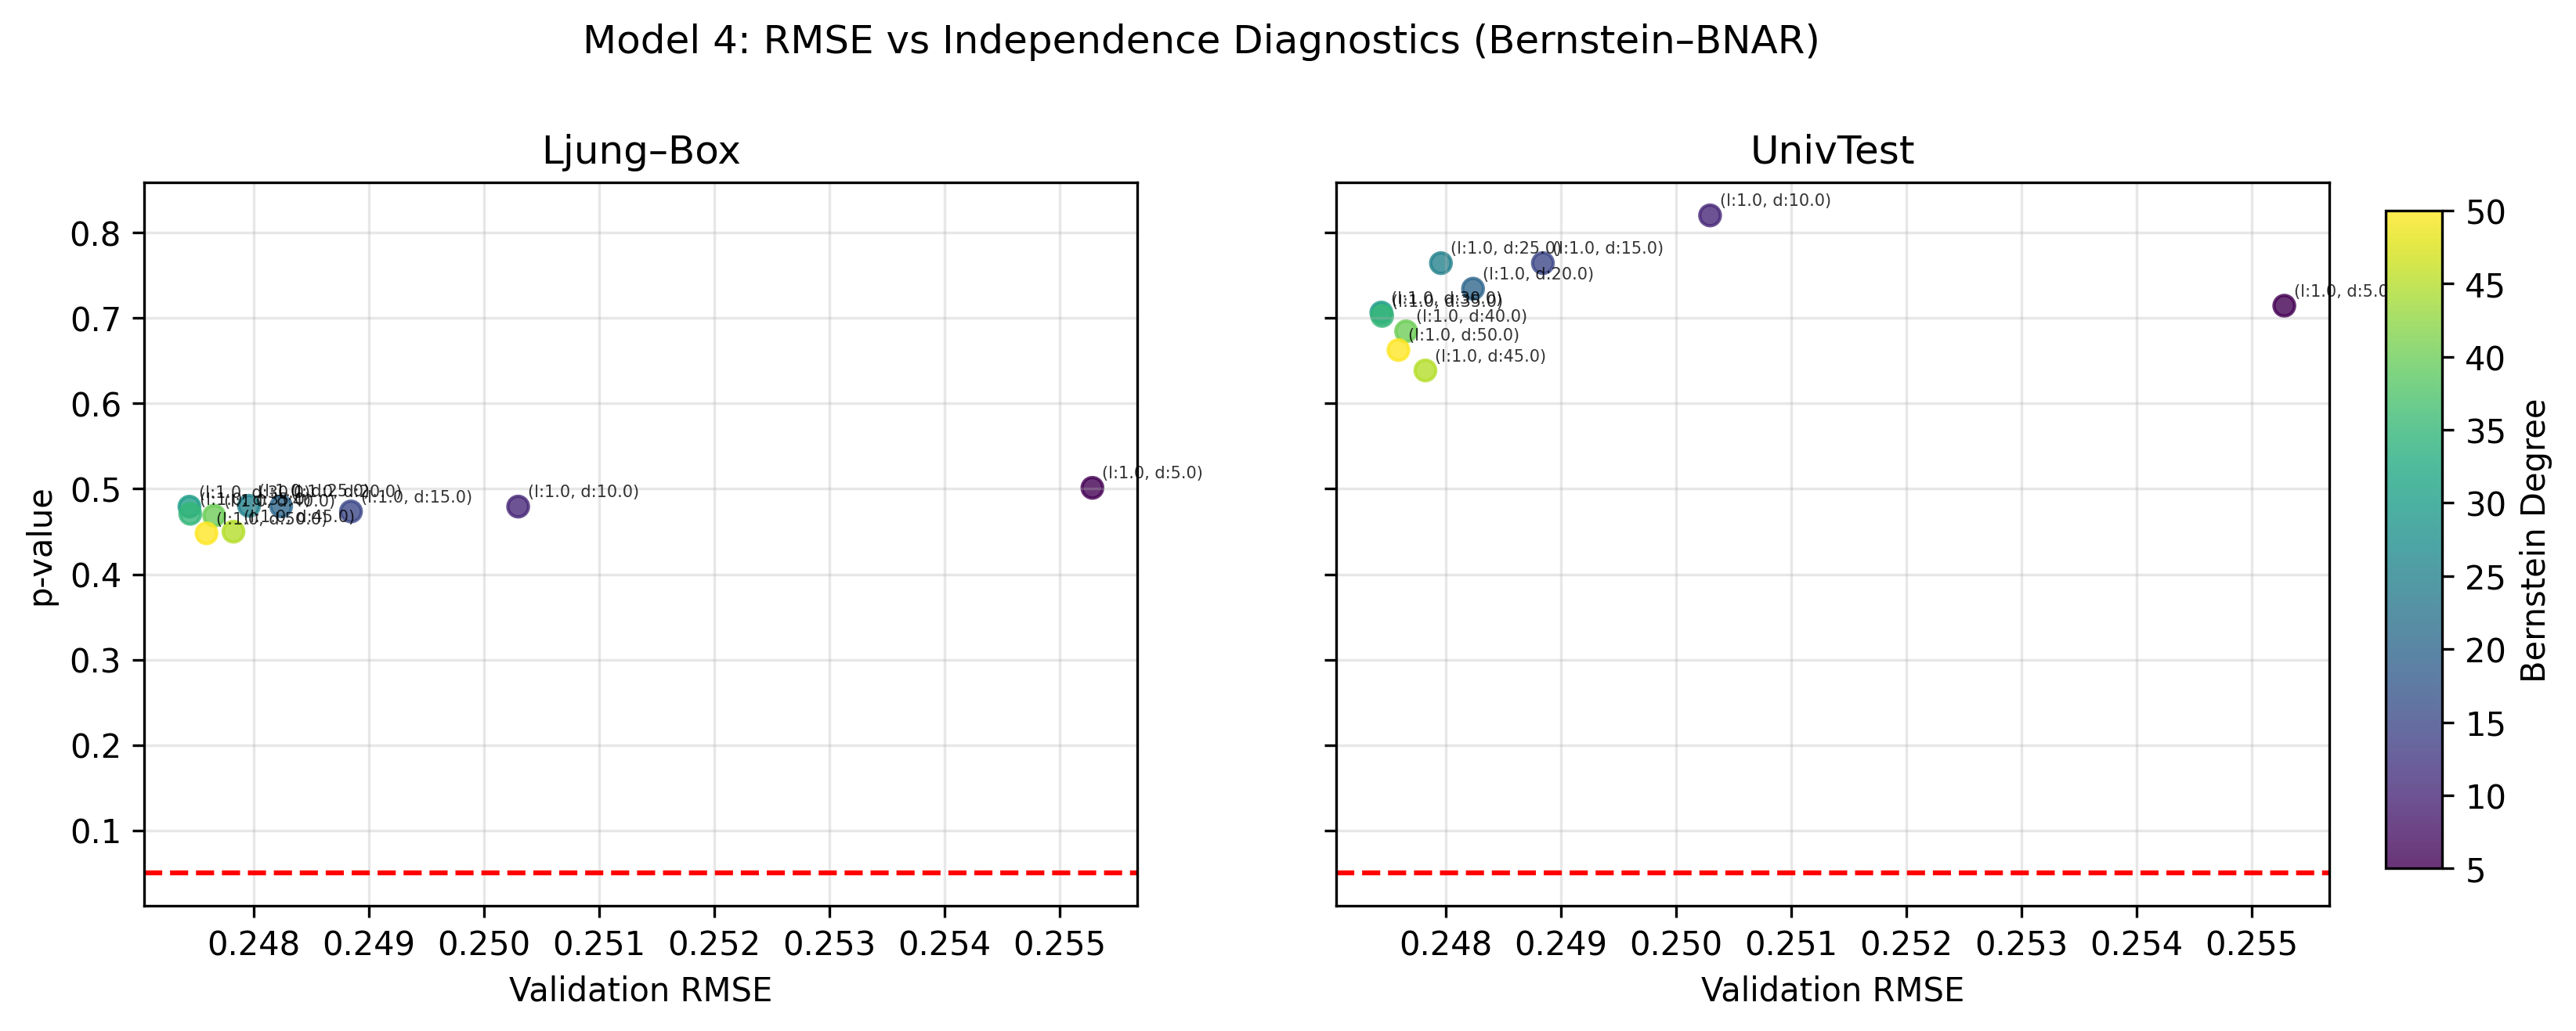

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# -----------------------------
# Left plot — Ljung–Box
# -----------------------------
scatter1 = axes[0].scatter(
    df_results["rmse_val"],
    df_results["lb_p_val"],
    c=df_results["degree"],
    cmap="viridis",
    s=40,
    alpha=0.8,
)

for _, row in df_results.iterrows():
    axes[0].annotate(
        f"(l:{row['d']}, d:{row['degree']})",
        (row["rmse_val"], row["lb_p_val"]),
        fontsize=5,
        alpha=0.8,
        xytext=(3, 3),
        textcoords="offset points",
    )

axes[0].axhline(0.05, color="red", linestyle="--")
axes[0].set_title("Ljung–Box")
axes[0].set_xlabel("Validation RMSE")
axes[0].set_ylabel("p-value")
axes[0].grid(True, alpha=0.3)

# -----------------------------
# Right plot — UnivTest
# -----------------------------
axes[1].scatter(
    df_results["rmse_val"],
    df_results["univ_p_val"],
    c=df_results["degree"],
    cmap="viridis",
    s=40,
    alpha=0.8,
)

for _, row in df_results.iterrows():
    axes[1].annotate(
        f"(l:{row['d']}, d:{row['degree']})",
        (row["rmse_val"], row["univ_p_val"]),
        fontsize=5,
        alpha=0.8,
        xytext=(3, 3),
        textcoords="offset points",
    )

axes[1].axhline(0.05, color="red", linestyle="--")
axes[1].set_title("UnivTest")
axes[1].set_xlabel("Validation RMSE")
axes[1].grid(True, alpha=0.3)

# -----------------------------
# Colorbar (rightmost)
# -----------------------------
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter1, cax=cbar_ax)
cbar.set_label("Bernstein Degree")

plt.suptitle(
    f"Model {id}: RMSE vs Independence Diagnostics (Bernstein–BNAR)",
    y=1.05
)

plt.show()

# Define Pareto Front

In [138]:
def pareto_front(df, rmse_col, pval_col):
    is_pareto = np.ones(len(df), dtype=bool)

    for i, row in df.iterrows():
        dominates = (
            (df[rmse_col] <= row[rmse_col]) &
            (df[pval_col] >= row[pval_col]) &
            (
                (df[rmse_col] < row[rmse_col]) |
                (df[pval_col] > row[pval_col])
            )
        )
        if dominates.any():
            is_pareto[i] = False

    return df[is_pareto]

df_pareto_lb = pareto_front(df_results, "rmse_val", "lb_p_val")
df_pareto_univ = pareto_front(df_results, "rmse_val", "univ_p_val")

# Visualize Pareto Front: Accuracy vs Residual Whiteness

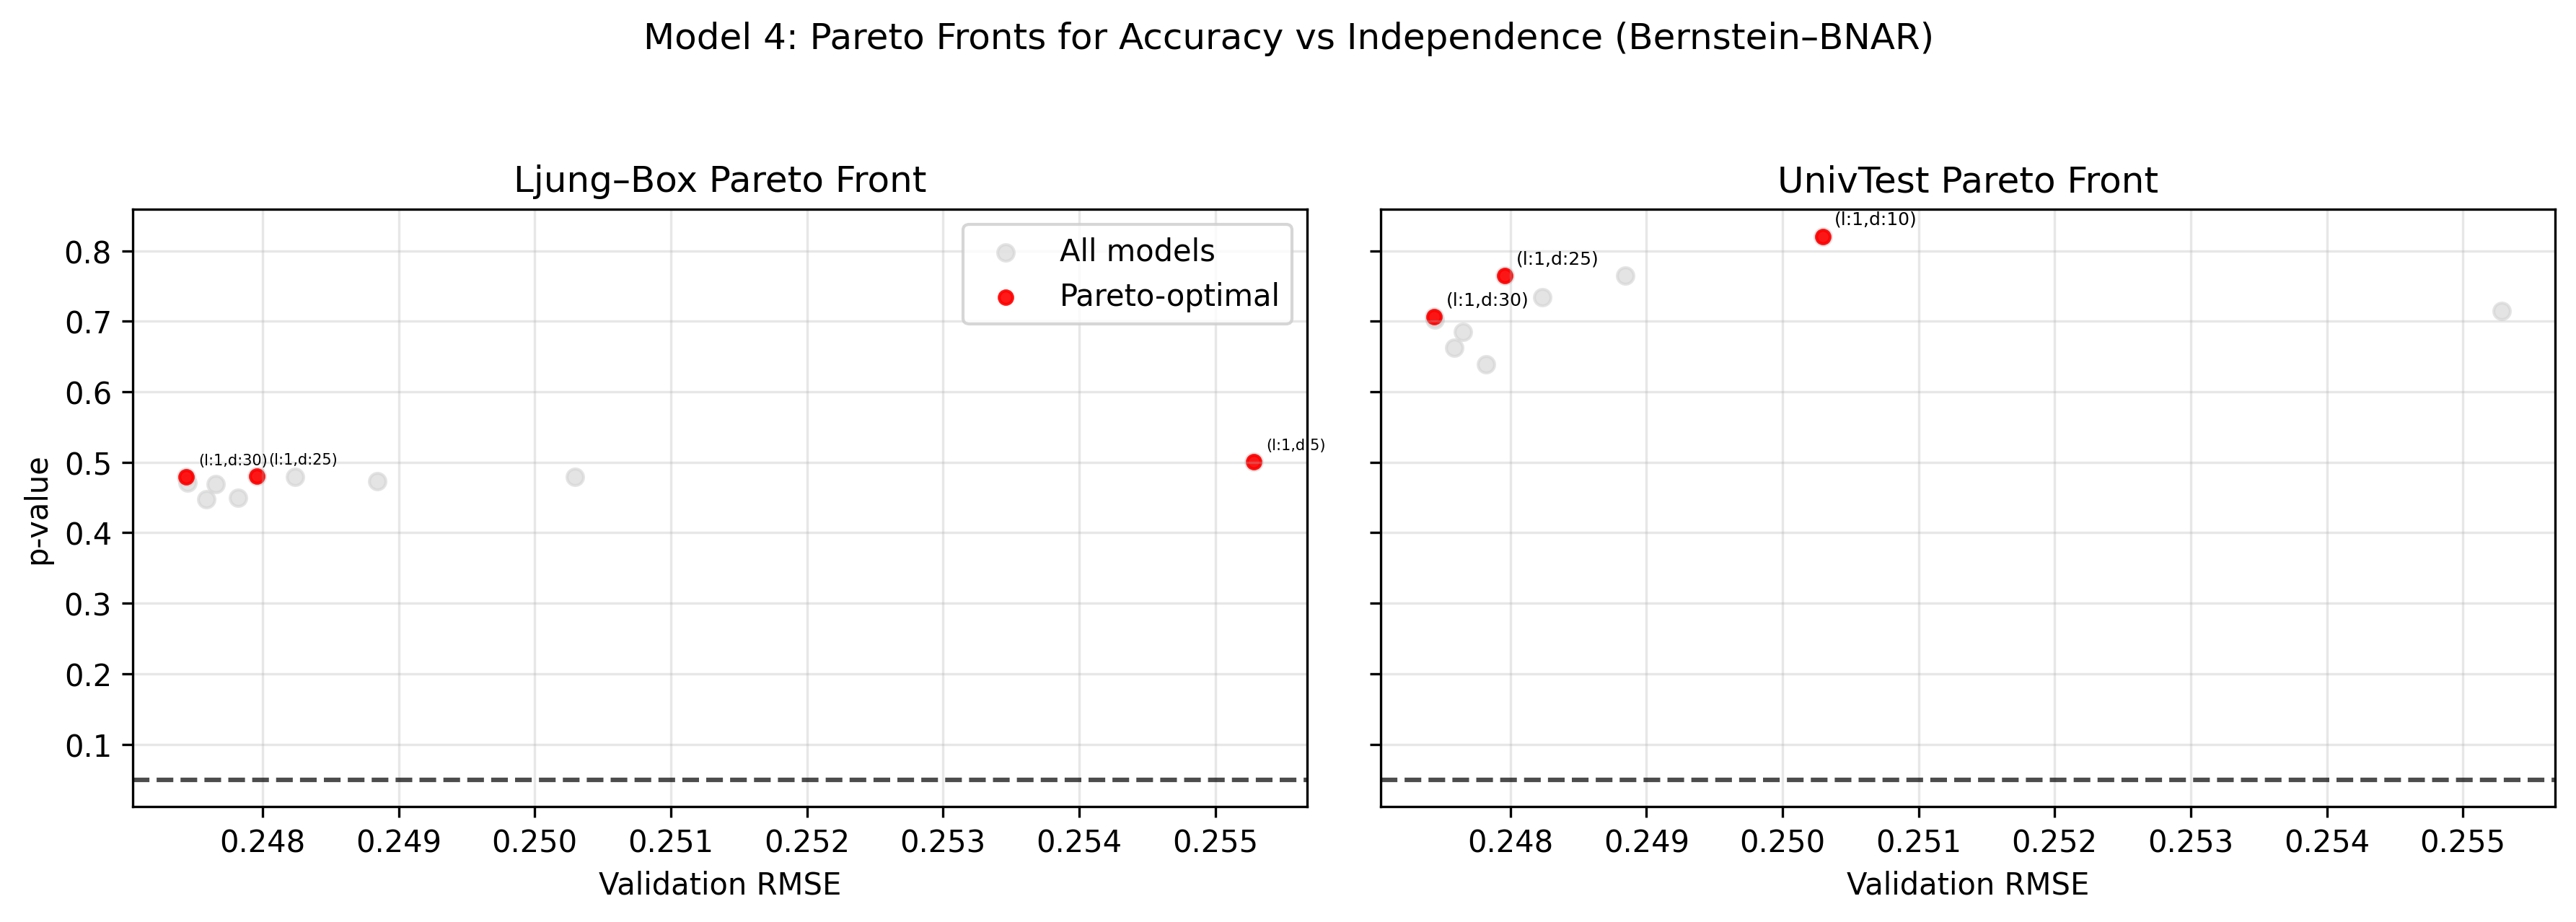

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# =====================================================
# LEFT — Ljung–Box Pareto
# =====================================================
axes[0].scatter(
    df_results["rmse_val"],
    df_results["lb_p_val"],
    c="lightgray",
    s=30,
    alpha=0.6,
    label="All models",
)

axes[0].scatter(
    df_pareto_lb["rmse_val"],
    df_pareto_lb["lb_p_val"],
    c="red",
    s=20,
    alpha=0.9,
    label="Pareto-optimal",
)

# Annotate ONLY Pareto points
for _, row in df_pareto_lb.iterrows():
    axes[0].annotate(
        f"(l:{int(row['d'])},d:{int(row['degree'])})",
        (row["rmse_val"], row["lb_p_val"]),
        fontsize=5,
        xytext=(4, 4),
        textcoords="offset points",
    )

axes[0].axhline(0.05, color="black", linestyle="--", alpha=0.7)
axes[0].set_title("Ljung–Box Pareto Front")
axes[0].set_xlabel("Validation RMSE")
axes[0].set_ylabel("p-value")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# =====================================================
# RIGHT — UnivTest Pareto
# =====================================================
axes[1].scatter(
    df_results["rmse_val"],
    df_results["univ_p_val"],
    c="lightgray",
    s=30,
    alpha=0.6,
)

axes[1].scatter(
    df_pareto_univ["rmse_val"],
    df_pareto_univ["univ_p_val"],
    c="red",
    s=20,
    alpha=0.9,
)


# Annotate ONLY Pareto points
for _, row in df_pareto_univ.iterrows():
    axes[1].annotate(
        f"(l:{int(row['d'])},d:{int(row['degree'])})",
        (row["rmse_val"], row["univ_p_val"]),
        fontsize=6,
        xytext=(4, 4),
        textcoords="offset points",
    )

axes[1].axhline(0.05, color="black", linestyle="--", alpha=0.7)
axes[1].set_title("UnivTest Pareto Front")
axes[1].set_xlabel("Validation RMSE")
axes[1].grid(True, alpha=0.3)

# =====================================================
# Global title
# =====================================================
plt.suptitle(
    f"Model {id}: Pareto Fronts for Accuracy vs Independence (Bernstein–BNAR)",
    y=1.05,
)

plt.tight_layout()
plt.show()

# Find out the Best Model

In [140]:
# Acceptable models
acceptable = df_results[df_results["lb_p_val"] >= 0.05]

# Best among acceptable
hard_best_model = acceptable.sort_values("rmse_val").iloc[0]

hard_best_model

,5
d,1.000000
degree,30.000000
rmse_train,0.268598
rmse_val,0.247439
rmse_test,0.260264
lb_p_train,0.282268
lb_p_val,0.479164
lb_p_test,0.020778
univ_p_train,0.934132
univ_p_val,0.706587


# Soft Best Model

In [141]:
# Soft compromise
soft_best_model = df_results.sort_values(
    by=["rmse_val", "lb_p_val"],
    ascending=[True, False]
).iloc[0]
soft_best_model

,5
d,1.000000
degree,30.000000
rmse_train,0.268598
rmse_val,0.247439
rmse_test,0.260264
lb_p_train,0.282268
lb_p_val,0.479164
lb_p_test,0.020778
univ_p_train,0.934132
univ_p_val,0.706587


# Evaluate


Training final model...
Epoch    0 | NELBO=3373.145 | Val RMSE=0.2963
Epoch  500 | NELBO=667.208 | Val RMSE=0.2475
Epoch 1000 | NELBO=303.407 | Val RMSE=0.2472
Epoch 1500 | NELBO=163.432 | Val RMSE=0.2473
Epoch 2000 | NELBO=108.533 | Val RMSE=0.2474
Epoch 2500 | NELBO=88.129 | Val RMSE=0.2475
Generating MC predictions...


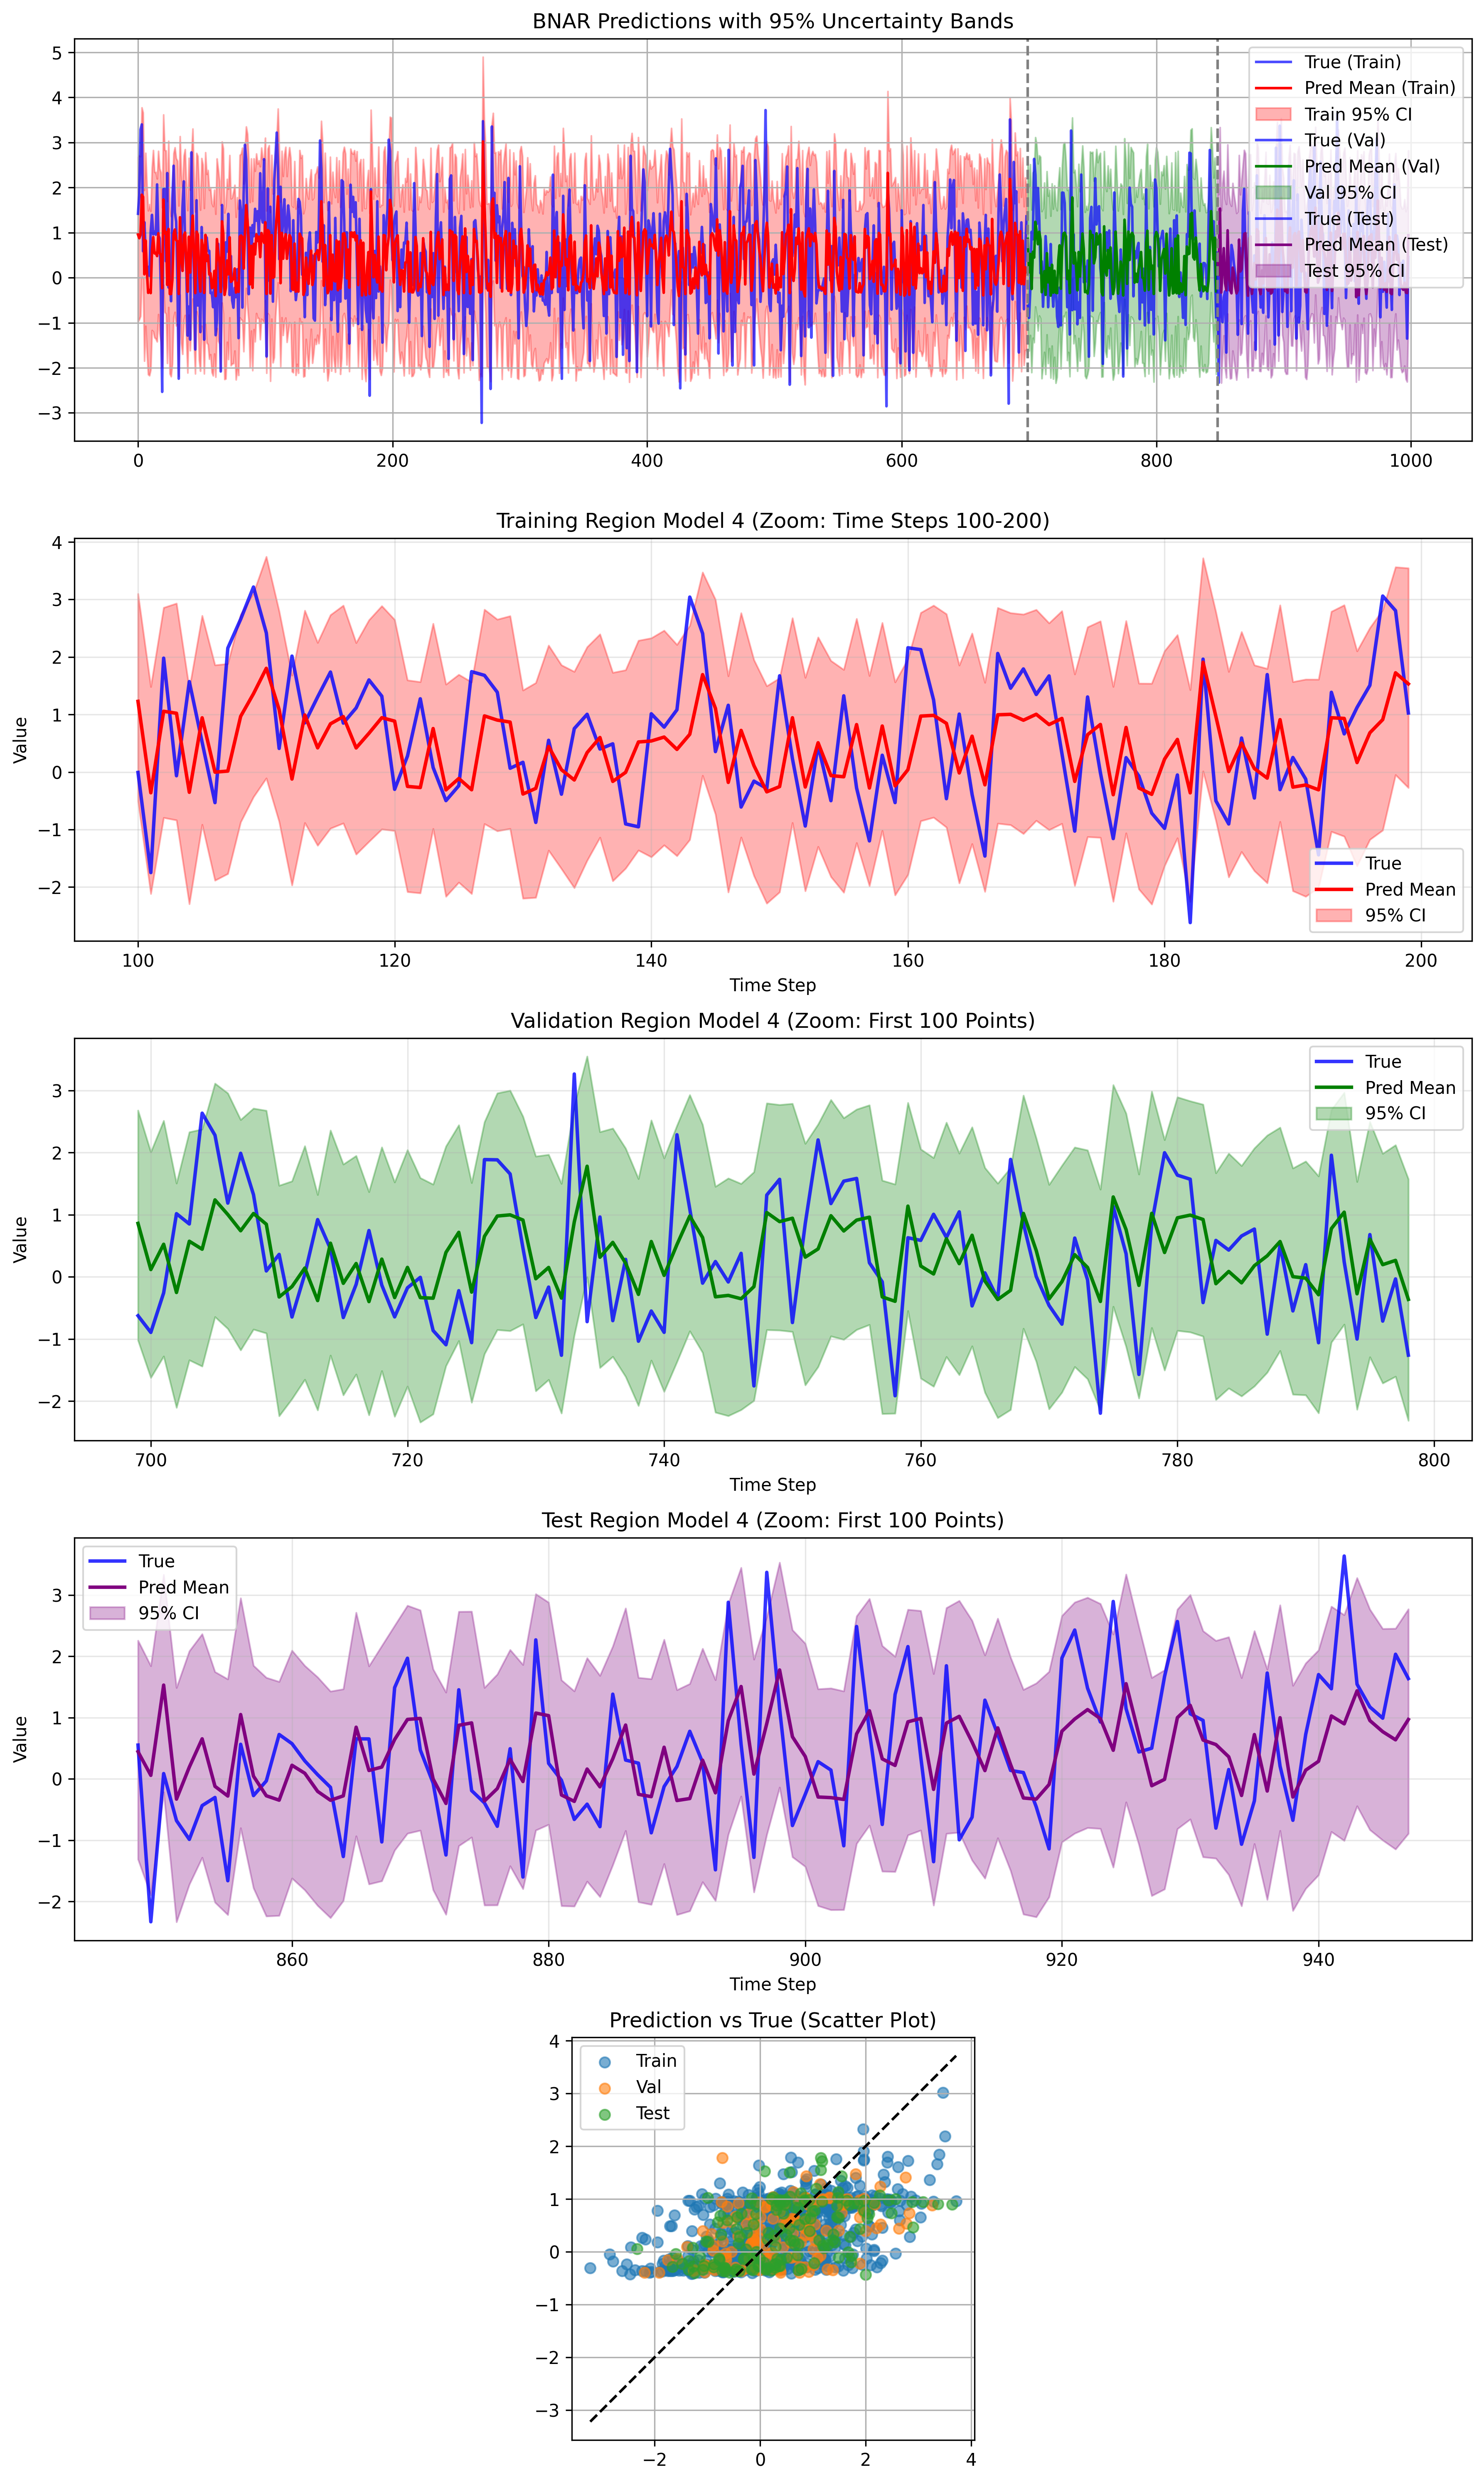

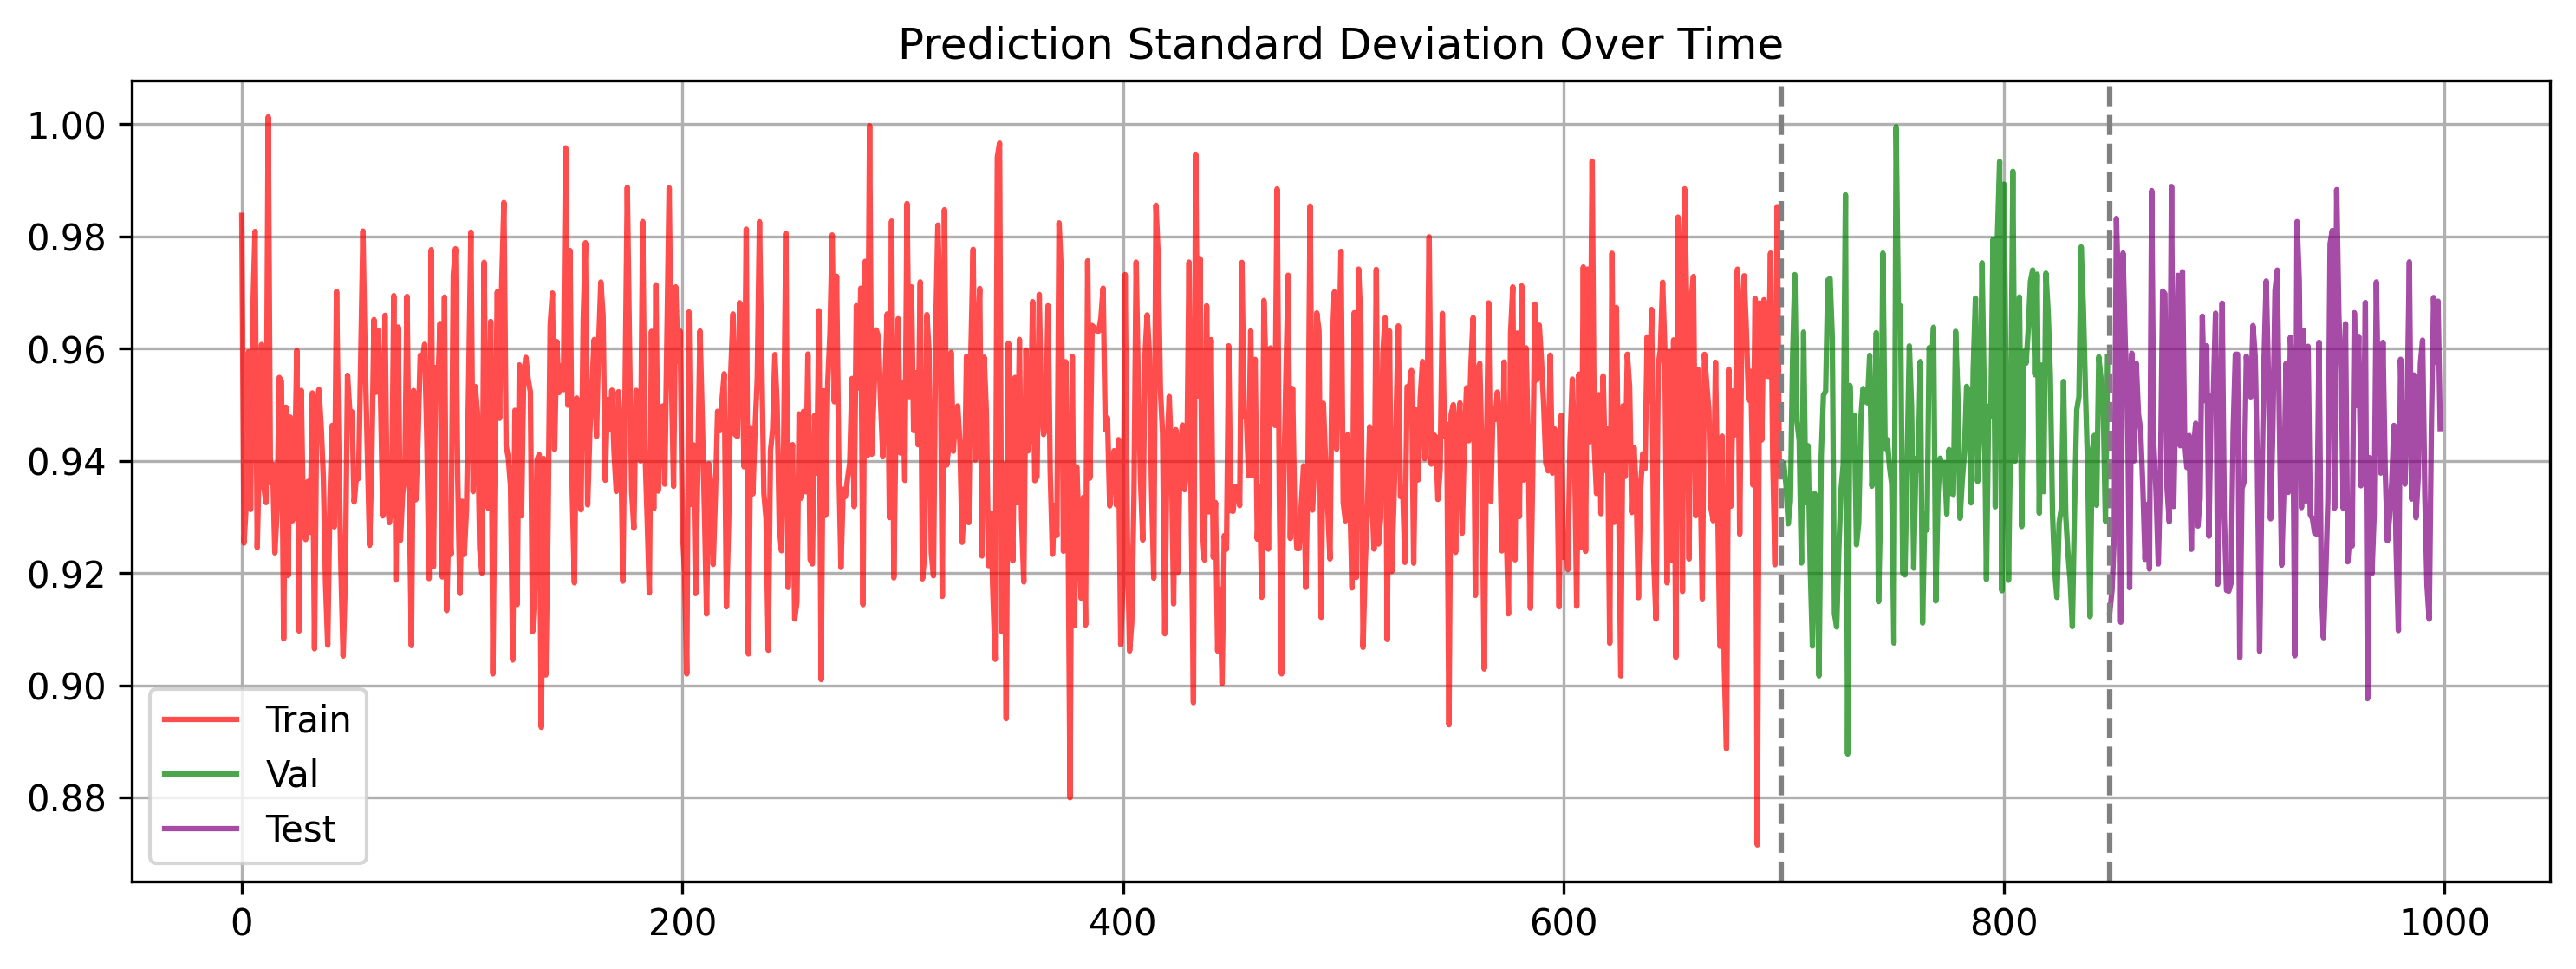

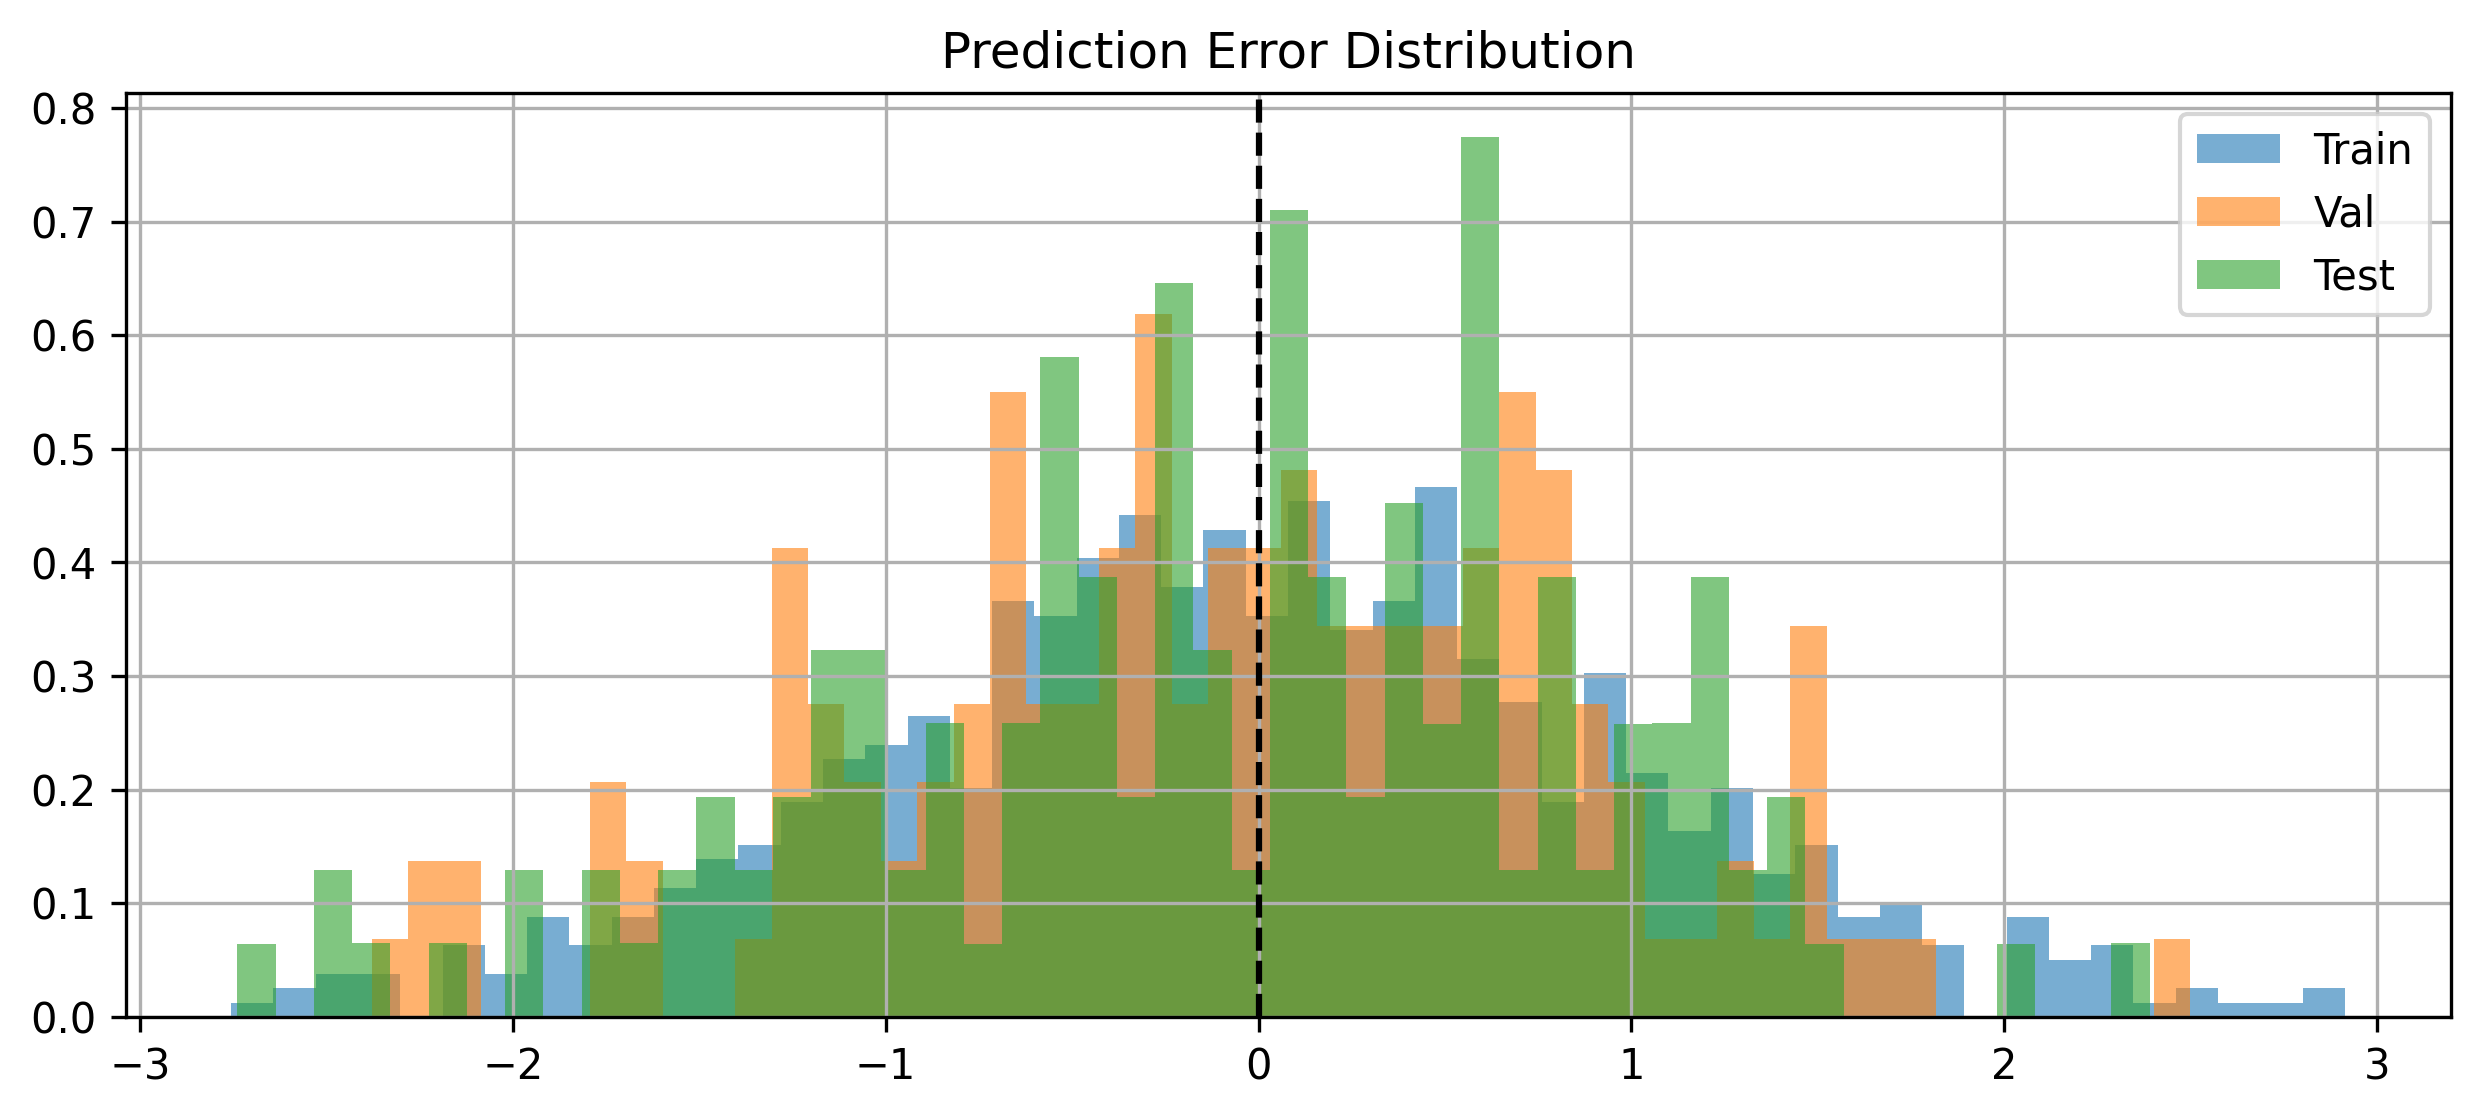


Coverage Probability (95% CI):
Train: 0.927
Val:   0.953
Test:  0.940

RMSE:
Train: 0.9971
Val:   0.9166
Test:  0.9726


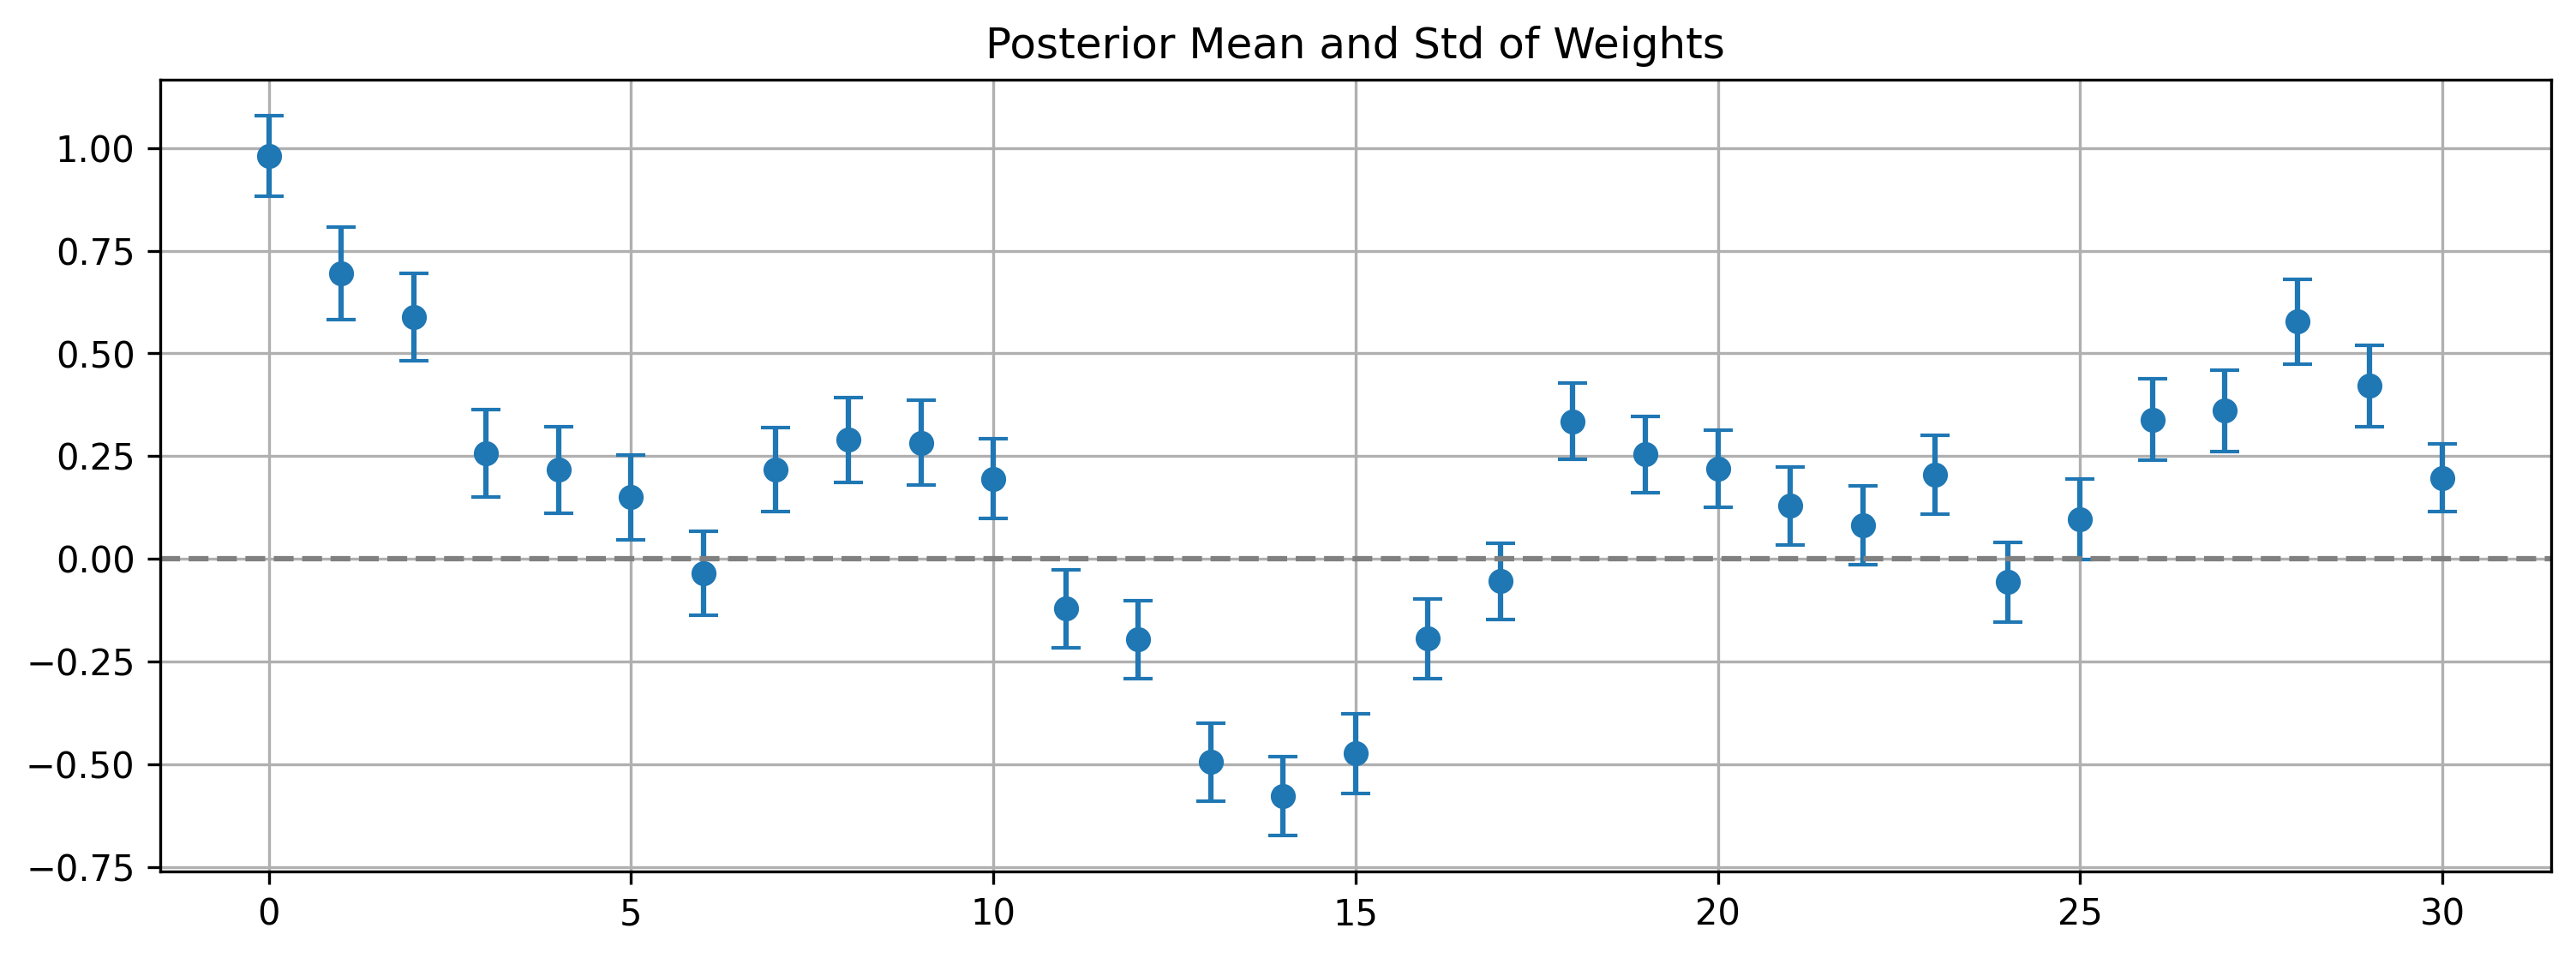

In [142]:
# ------------------------------------------------------------
# 1. Monte-Carlo Prediction with Uncertainty + Inverse Scaling
# ------------------------------------------------------------
def predict_with_uncertainty(model, X, n_samples=1000, scale_factor=1.0):
    """
    Generate predictive samples & compute mean, std, CI.
    Automatically inverts scaling using scale_factor.
    """
    model.eval()
    with torch.no_grad():
        samples = []
        for _ in range(n_samples):
            yhat, sigma_eps, _ = model.forward(X, sample=True, kl_weight=0.0)
            noisy = yhat + torch.randn_like(yhat) * sigma_eps
            samples.append(noisy.cpu().numpy())

        # shape: (N, samples)
        samples = np.array(samples).squeeze(-1).T

        # inverse scaling
        samples = samples * scale_factor

        # predictive stats
        pred_mean  = np.mean(samples, axis=1)
        pred_std   = np.std(samples, axis=1)
        pred_lower = np.percentile(samples, 2.5, axis=1)
        pred_upper = np.percentile(samples, 97.5, axis=1)

        return pred_mean, pred_std, pred_lower, pred_upper, samples

##############################################################
d = int(hard_best_model["d"])
degree = int(hard_best_model["degree"])
# -------------------------
# Build lagged design
# -------------------------
X_lag, y = build_lag_matrix(x_scaled, d)

X_basis = build_bernstein_full_basis(X_lag, degree=degree)

N = len(y)
n_train = int(0.7 * N)
n_val   = int(0.15 * N)

idx_tr = slice(0, n_train)
idx_va = slice(n_train, n_train + n_val)
idx_te = slice(n_train + n_val, N)

Xtr, ytr = X_basis[idx_tr], y[idx_tr]
Xva, yva = X_basis[idx_va], y[idx_va]
Xte, yte = X_basis[idx_te], y[idx_te]

Xtr_t = torch.tensor(Xtr, dtype=torch.float32, device=device)
ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).unsqueeze(1)
Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
yva_t = torch.tensor(yva, dtype=torch.float32, device=device).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32, device=device)
yte_t = torch.tensor(yte, dtype=torch.float32, device=device).unsqueeze(1)

# ------------------------------------------------------------
# Build models and Train for Train/Val/Test
# ------------------------------------------------------------
model = BNAR_FullCov(
    d=Xtr.shape[1],
    activation='tanh',
    prior_std=1.0,
    sigma_floor=1e-6
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("\nTraining final model...")

for epoch in range(3000):
    model.train()
    optimizer.zero_grad()

    nelbo, _ = model.negative_elbo(Xtr_t, ytr_t, kl_weight=0.1)
    nelbo.backward()
    optimizer.step()

    if epoch % 500 == 0:
        model.eval()
        with torch.no_grad():
            yhat_va, _, _ = model.forward(Xva_t, sample=False)
            rmse_va = torch.sqrt(torch.mean((yva_t - yhat_va)**2))
        print(f"Epoch {epoch:4d} | NELBO={nelbo.item():.3f} | Val RMSE={rmse_va.item():.4f}")

# ------------------------------------------------------------
# 2. Generate Predictions for Train/Val/Test
# ------------------------------------------------------------
print("Generating MC predictions...")

ytr_pred_mean, ytr_pred_std, ytr_pred_lower, ytr_pred_upper, tr_samples = \
    predict_with_uncertainty(model, Xtr_t, n_samples=1000, scale_factor=c)

yva_pred_mean, yva_pred_std, yva_pred_lower, yva_pred_upper, va_samples = \
    predict_with_uncertainty(model, Xva_t, n_samples=1000, scale_factor=c)

yte_pred_mean, yte_pred_std, yte_pred_lower, yte_pred_upper, te_samples = \
    predict_with_uncertainty(model, Xte_t, n_samples=1000, scale_factor=c)


# ------------------------------------------------------------
# 3. Inverse-Scaled True Values
# ------------------------------------------------------------
ytr_true = ytr_t.cpu().numpy().flatten() * c
yva_true = yva_t.cpu().numpy().flatten() * c
yte_true = yte_t.cpu().numpy().flatten() * c


# ------------------------------------------------------------
# 4. Time Indices
# ------------------------------------------------------------
time_tr = np.arange(len(ytr_true))
time_va = np.arange(len(ytr_true), len(ytr_true) + len(yva_true))
time_te = np.arange(len(ytr_true) + len(yva_true),
                    len(ytr_true) + len(yva_true) + len(yte_true))


# ============================================================
#                   FULL VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(12, 20))

# ---------------------------
# Plot 1 — Full Series
# ---------------------------
ax1 = plt.subplot(5,1,1)

# Train
ax1.plot(time_tr, ytr_true, 'b-', label='True (Train)', alpha=0.7)
ax1.plot(time_tr, ytr_pred_mean, 'r-', label='Pred Mean (Train)')
ax1.fill_between(time_tr, ytr_pred_lower, ytr_pred_upper,
                 color='red', alpha=0.3, label='Train 95% CI')

# Val
ax1.plot(time_va, yva_true, 'b-', alpha=0.7, label='True (Val)')
ax1.plot(time_va, yva_pred_mean, 'g-', label='Pred Mean (Val)')
ax1.fill_between(time_va, yva_pred_lower, yva_pred_upper,
                 color='green', alpha=0.3, label='Val 95% CI')

# Test
ax1.plot(time_te, yte_true, 'b-', alpha=0.7, label='True (Test)')
ax1.plot(time_te, yte_pred_mean, 'purple', label='Pred Mean (Test)')
ax1.fill_between(time_te, yte_pred_lower, yte_pred_upper,
                 color='purple', alpha=0.3, label='Test 95% CI')

ax1.axvline(len(ytr_true), color='gray', linestyle='--')
ax1.axvline(len(ytr_true) + len(yva_true), color='gray', linestyle='--')

ax1.set_title("BNAR Predictions with 95% Uncertainty Bands")
ax1.legend()
ax1.grid(True)


# Plot 2: Training region zoom
ax2 = plt.subplot(5, 1, 2)
ax2.plot(time_tr[100:200], ytr_true[100:200], 'b-', alpha=0.8, label='True', linewidth=2)
ax2.plot(time_tr[100:200], ytr_pred_mean[100:200], 'r-', label='Pred Mean', linewidth=2)
ax2.fill_between(time_tr[100:200], ytr_pred_lower[100:200], ytr_pred_upper[100:200],
                      alpha=0.3, color='red', label='95% CI')
ax2.set_title(f'Training Region Model {id} (Zoom: Time Steps 100-200)')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Validation region zoom
ax3 = plt.subplot(5, 1, 3)
ax3.plot(time_va[:100], yva_true[:100], 'b-', alpha=0.8, label='True', linewidth=2)
ax3.plot(time_va[:100], yva_pred_mean[:100], 'g-', label='Pred Mean', linewidth=2)
ax3.fill_between(time_va[:100], yva_pred_lower[:100], yva_pred_upper[:100],
                      alpha=0.3, color='green', label='95% CI')
ax3.set_title(f'Validation Region Model {id} (Zoom: First 100 Points)')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Value')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Test region zoom
ax4 = plt.subplot(5, 1, 4)
ax4.plot(time_te[:100], yte_true[:100], 'b-', alpha=0.8, label='True', linewidth=2)
ax4.plot(time_te[:100], yte_pred_mean[:100], 'purple', label='Pred Mean', linewidth=2)
ax4.fill_between(time_te[:100], yte_pred_lower[:100], yte_pred_upper[:100],
                      alpha=0.3, color='purple', label='95% CI')
ax4.set_title(f'Test Region Model {id} (Zoom: First 100 Points)')
ax4.set_xlabel('Time Step')
ax4.set_ylabel('Value')
ax4.legend()
ax4.grid(True, alpha=0.3)




# ---------------------------
# Plot 5 — Scatter (True vs Pred)
# ---------------------------
ax5 = plt.subplot(5,1,5)

ax5.scatter(ytr_true, ytr_pred_mean, alpha=0.6, label='Train')
ax5.scatter(yva_true, yva_pred_mean, alpha=0.6, label='Val')
ax5.scatter(yte_true, yte_pred_mean, alpha=0.6, label='Test')

mn = min(ytr_true.min(), ytr_pred_mean.min())
mx = max(ytr_true.max(), ytr_pred_mean.max())
ax5.plot([mn, mx], [mn, mx], 'k--')

ax5.set_title("Prediction vs True (Scatter Plot)")
ax5.set_aspect("equal")
ax5.grid(True)
ax5.legend()

plt.tight_layout()
plt.show()


# ============================================================
#                   UNCERTAINTY + ERRORS
# ============================================================

# ---------------------------
# 6 — Uncertainty Over Time
# ---------------------------
plt.figure(figsize=(12,4))
plt.plot(time_tr, ytr_pred_std, 'r-', alpha=0.7, label='Train')
plt.plot(time_va, yva_pred_std, 'g-', alpha=0.7, label='Val')
plt.plot(time_te, yte_pred_std, 'purple', alpha=0.7, label='Test')
plt.axvline(len(ytr_true), color='gray', linestyle='--')
plt.axvline(len(ytr_true)+len(yva_true), color='gray', linestyle='--')
plt.title("Prediction Standard Deviation Over Time")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------
# 7 — Error Histogram
# ---------------------------
plt.figure(figsize=(10,4))

err_tr = ytr_pred_mean - ytr_true
err_va = yva_pred_mean - yva_true
err_te = yte_pred_mean - yte_true

plt.hist(err_tr, bins=50, density=True, alpha=0.6, label='Train')
plt.hist(err_va, bins=50, density=True, alpha=0.6, label='Val')
plt.hist(err_te, bins=50, density=True, alpha=0.6, label='Test')
plt.axvline(0, color='k', linestyle='--')
plt.title("Prediction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------
# 8 — Coverage Probability (95%)
# ---------------------------
coverage_tr = np.mean((ytr_true >= ytr_pred_lower) & (ytr_true <= ytr_pred_upper))
coverage_va = np.mean((yva_true >= yva_pred_lower) & (yva_true <= yva_pred_upper))
coverage_te = np.mean((yte_true >= yte_pred_lower) & (yte_true <= yte_pred_upper))

print("\nCoverage Probability (95% CI):")
print(f"Train: {coverage_tr:.3f}")
print(f"Val:   {coverage_va:.3f}")
print(f"Test:  {coverage_te:.3f}")


# ---------------------------
# 9 — RMSE
# ---------------------------
rmse_tr = np.sqrt(np.mean(err_tr**2))
rmse_va = np.sqrt(np.mean(err_va**2))
rmse_te = np.sqrt(np.mean(err_te**2))

print("\nRMSE:")
print(f"Train: {rmse_tr:.4f}")
print(f"Val:   {rmse_va:.4f}")
print(f"Test:  {rmse_te:.4f}")


# ---------------------------
# 10 — Posterior Weights Mean and Std
# ---------------------------
weights = model.m_w.detach().cpu().numpy()
stds = torch.exp(model.log_diag_Lq).detach().cpu().numpy()

plt.figure(figsize=(12,4))
plt.errorbar(np.arange(len(weights)), weights, yerr=stds,
             fmt='o', capsize=4)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Posterior Mean and Std of Weights")
plt.grid(True)
plt.show()

# Normlity Test for residuals


Train Residual Normality Tests
---------------------------------------------
Shapiro-Wilk:  stat=0.9982, p=0.6984
Jarque-Bera:   stat=0.5365, p=0.7647

Validation Residual Normality Tests
---------------------------------------------
Shapiro-Wilk:  stat=0.9932, p=0.7077
Jarque-Bera:   stat=0.7376, p=0.6916

Test Residual Normality Tests
---------------------------------------------
Shapiro-Wilk:  stat=0.9890, p=0.2813
Jarque-Bera:   stat=2.6039, p=0.272


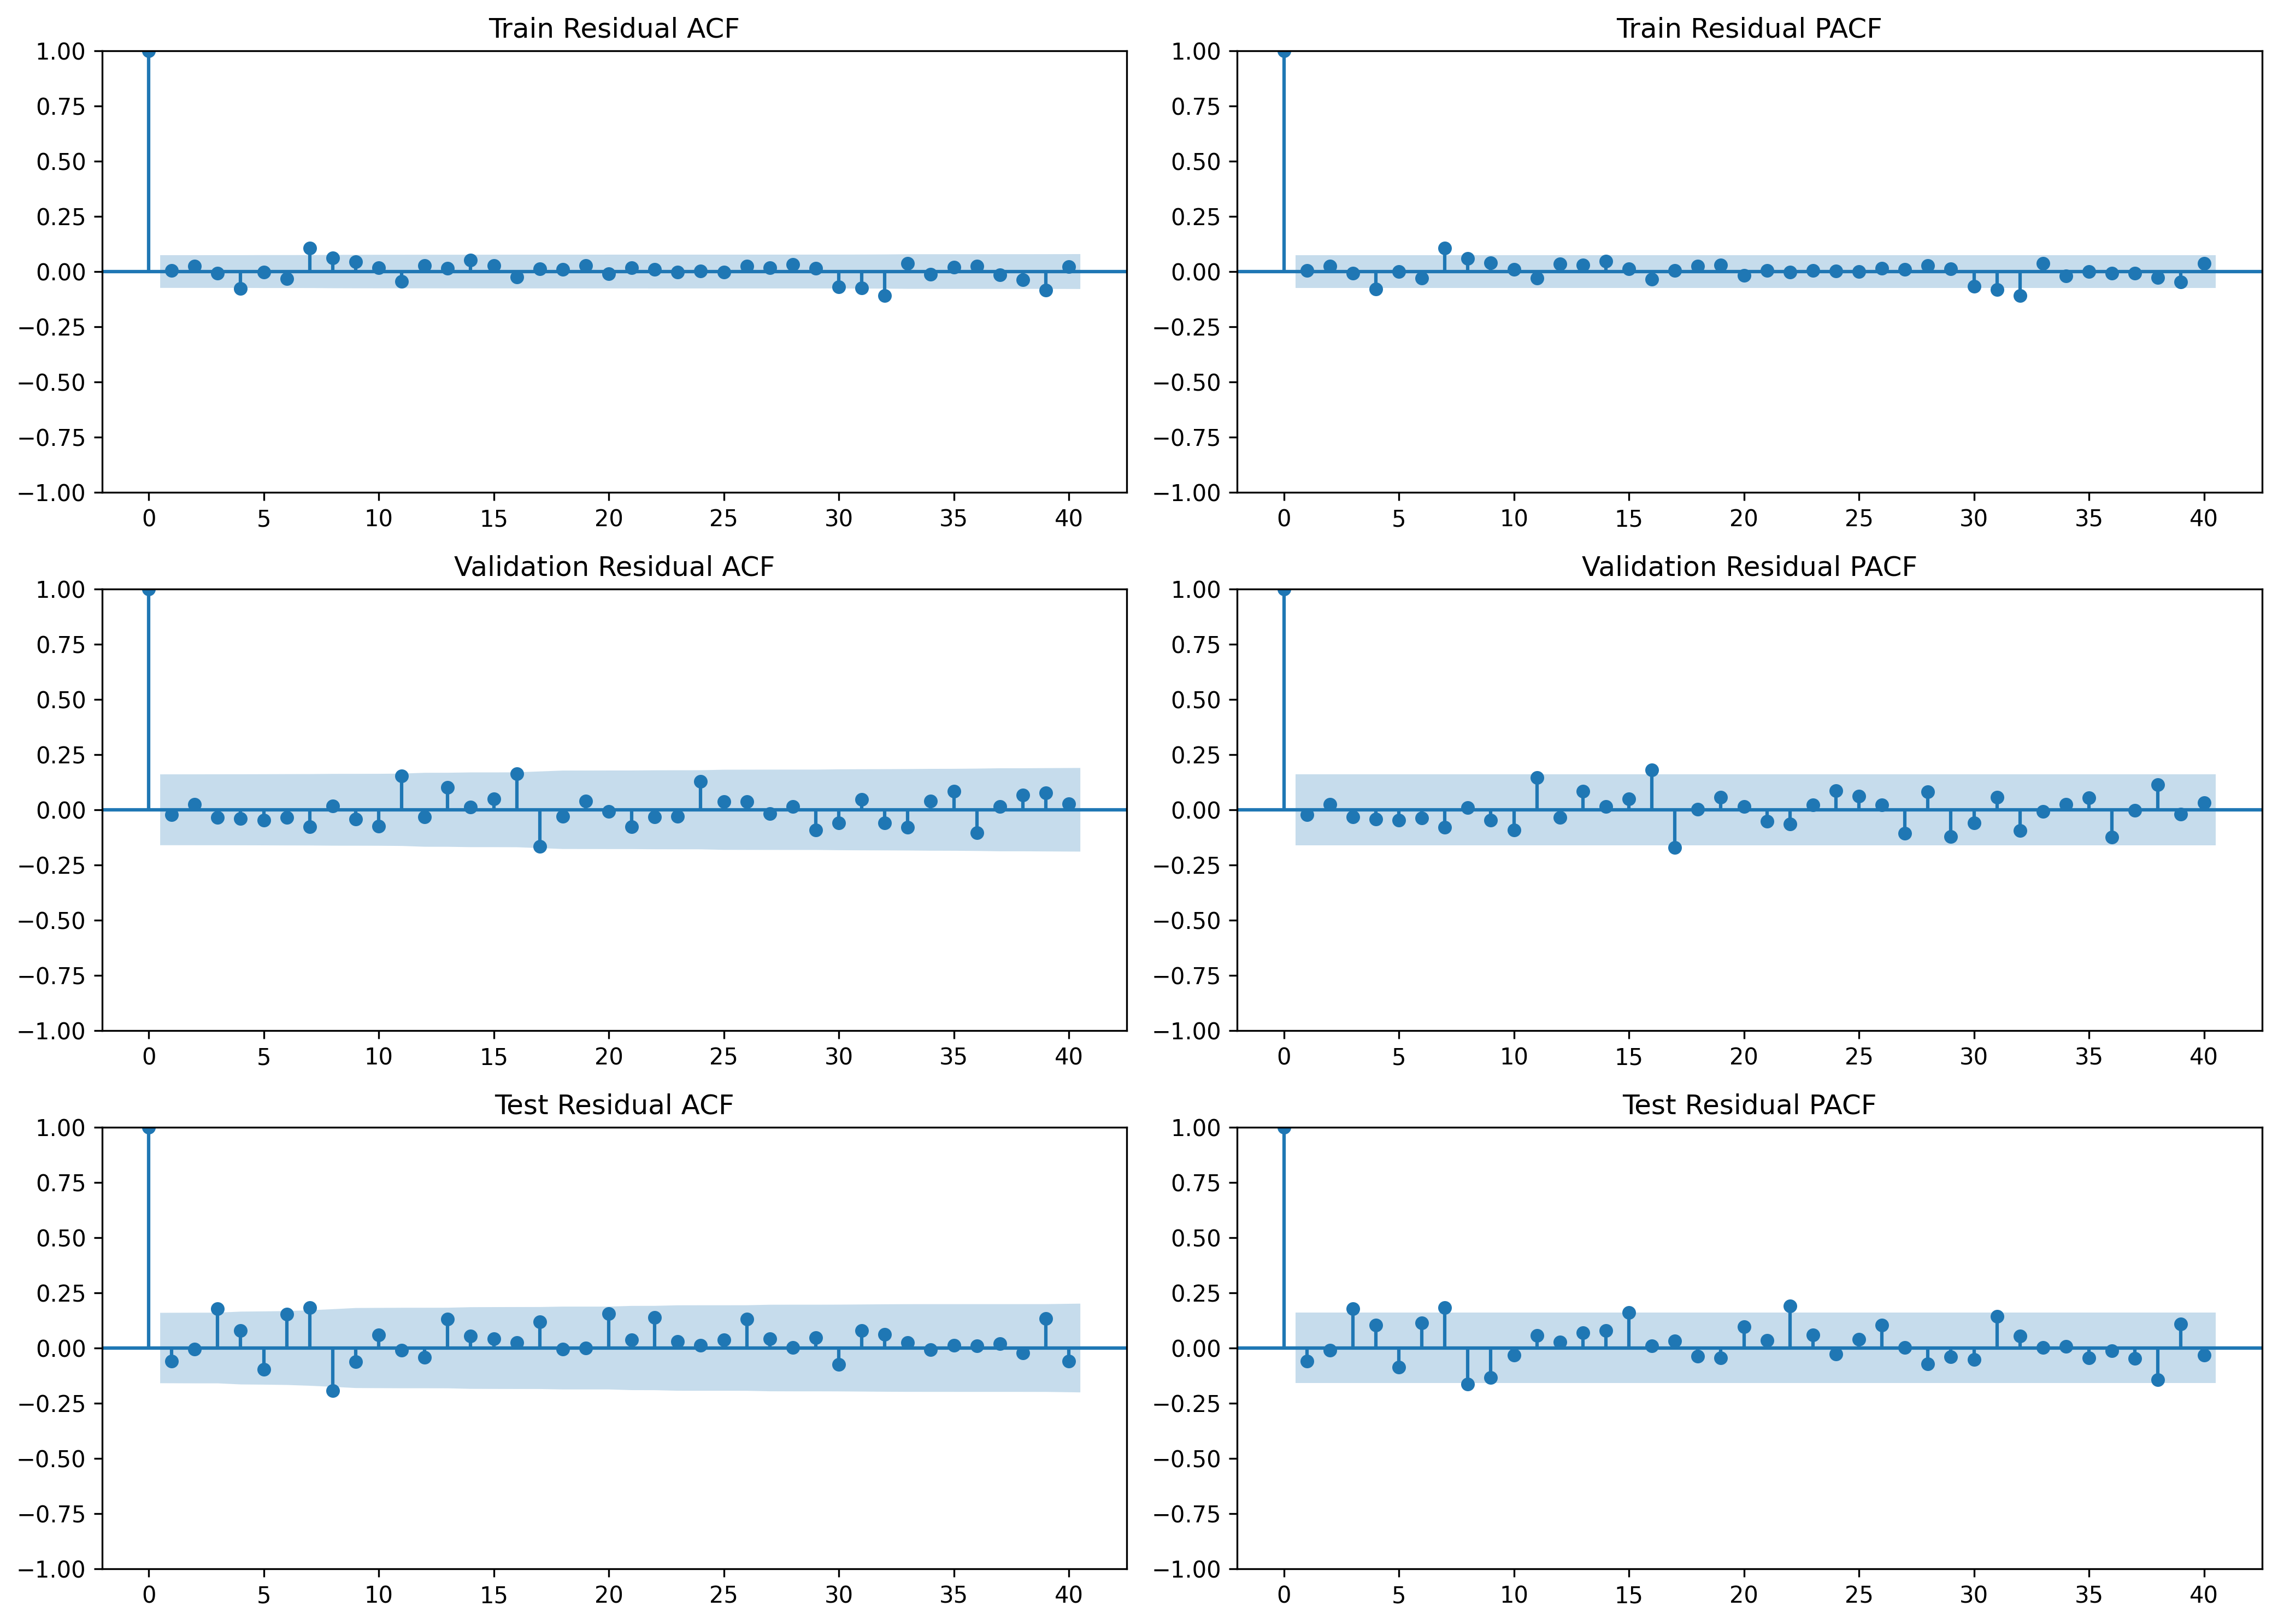


Train Ljung-Box Test (lag=20)
---------------------------------------------
LB statistic = 23.6925
p-value      = 0.2561

Validation Ljung-Box Test (lag=20)
---------------------------------------------
LB statistic = 19.0607
p-value      = 0.5179

Test Ljung-Box Test (lag=20)
---------------------------------------------
LB statistic = 35.2335
p-value      = 0.0189


In [143]:
# ============================================================
#            RESIDUAL DIAGNOSTICS FOR BNAR
# ============================================================

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ------------------------------------------------------------
# 1. Compute residuals
# ------------------------------------------------------------
res_tr = ytr_true - ytr_pred_mean
res_va = yva_true - yva_pred_mean
res_te = yte_true - yte_pred_mean

# ------------------------------------------------------------
# 2. Normality tests (Shapiro + Jarque-Bera)
# ------------------------------------------------------------
def normality_tests(residuals, name=""):
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    jb_stat, jb_p = stats.jarque_bera(residuals)

    print(f"\n{name} Residual Normality Tests")
    print("-" * 45)
    print(f"Shapiro-Wilk:  stat={shapiro_stat:.4f}, p={shapiro_p:.4g}")
    print(f"Jarque-Bera:   stat={jb_stat:.4f}, p={jb_p:.4g}")

normality_tests(res_tr, "Train")
normality_tests(res_va, "Validation")
normality_tests(res_te, "Test")


# ------------------------------------------------------------
# 3. Residual ACF / PACF plots
# ------------------------------------------------------------
max_lag = 40

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

plot_acf(res_tr, lags=max_lag, ax=axes[0,0])
plot_pacf(res_tr, lags=max_lag, ax=axes[0,1], method="ywm")
axes[0,0].set_title("Train Residual ACF")
axes[0,1].set_title("Train Residual PACF")

plot_acf(res_va, lags=max_lag, ax=axes[1,0])
plot_pacf(res_va, lags=max_lag, ax=axes[1,1], method="ywm")
axes[1,0].set_title("Validation Residual ACF")
axes[1,1].set_title("Validation Residual PACF")

plot_acf(res_te, lags=max_lag, ax=axes[2,0])
plot_pacf(res_te, lags=max_lag, ax=axes[2,1], method="ywm")
axes[2,0].set_title("Test Residual ACF")
axes[2,1].set_title("Test Residual PACF")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Ljung-Box test (whiteness test)
# ------------------------------------------------------------
def ljung_box_test(residuals, name="", lags=20):
    lb = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    stat = lb["lb_stat"].values[0]
    pval = lb["lb_pvalue"].values[0]

    print(f"\n{name} Ljung-Box Test (lag={lags})")
    print("-" * 45)
    print(f"LB statistic = {stat:.4f}")
    print(f"p-value      = {pval:.4g}")

ljung_box_test(res_tr, "Train")
ljung_box_test(res_va, "Validation")
ljung_box_test(res_te, "Test")

# Residual Test on standardized residuals


Train STANDARDIZED Residual Normality Tests
-------------------------------------------------------
Shapiro-Wilk:  stat=0.9983, p=0.7217
Jarque-Bera:   stat=0.4543, p=0.7968

Validation STANDARDIZED Residual Normality Tests
-------------------------------------------------------
Shapiro-Wilk:  stat=0.9940, p=0.8012
Jarque-Bera:   stat=0.6431, p=0.725

Test STANDARDIZED Residual Normality Tests
-------------------------------------------------------
Shapiro-Wilk:  stat=0.9894, p=0.3115
Jarque-Bera:   stat=2.5448, p=0.2802


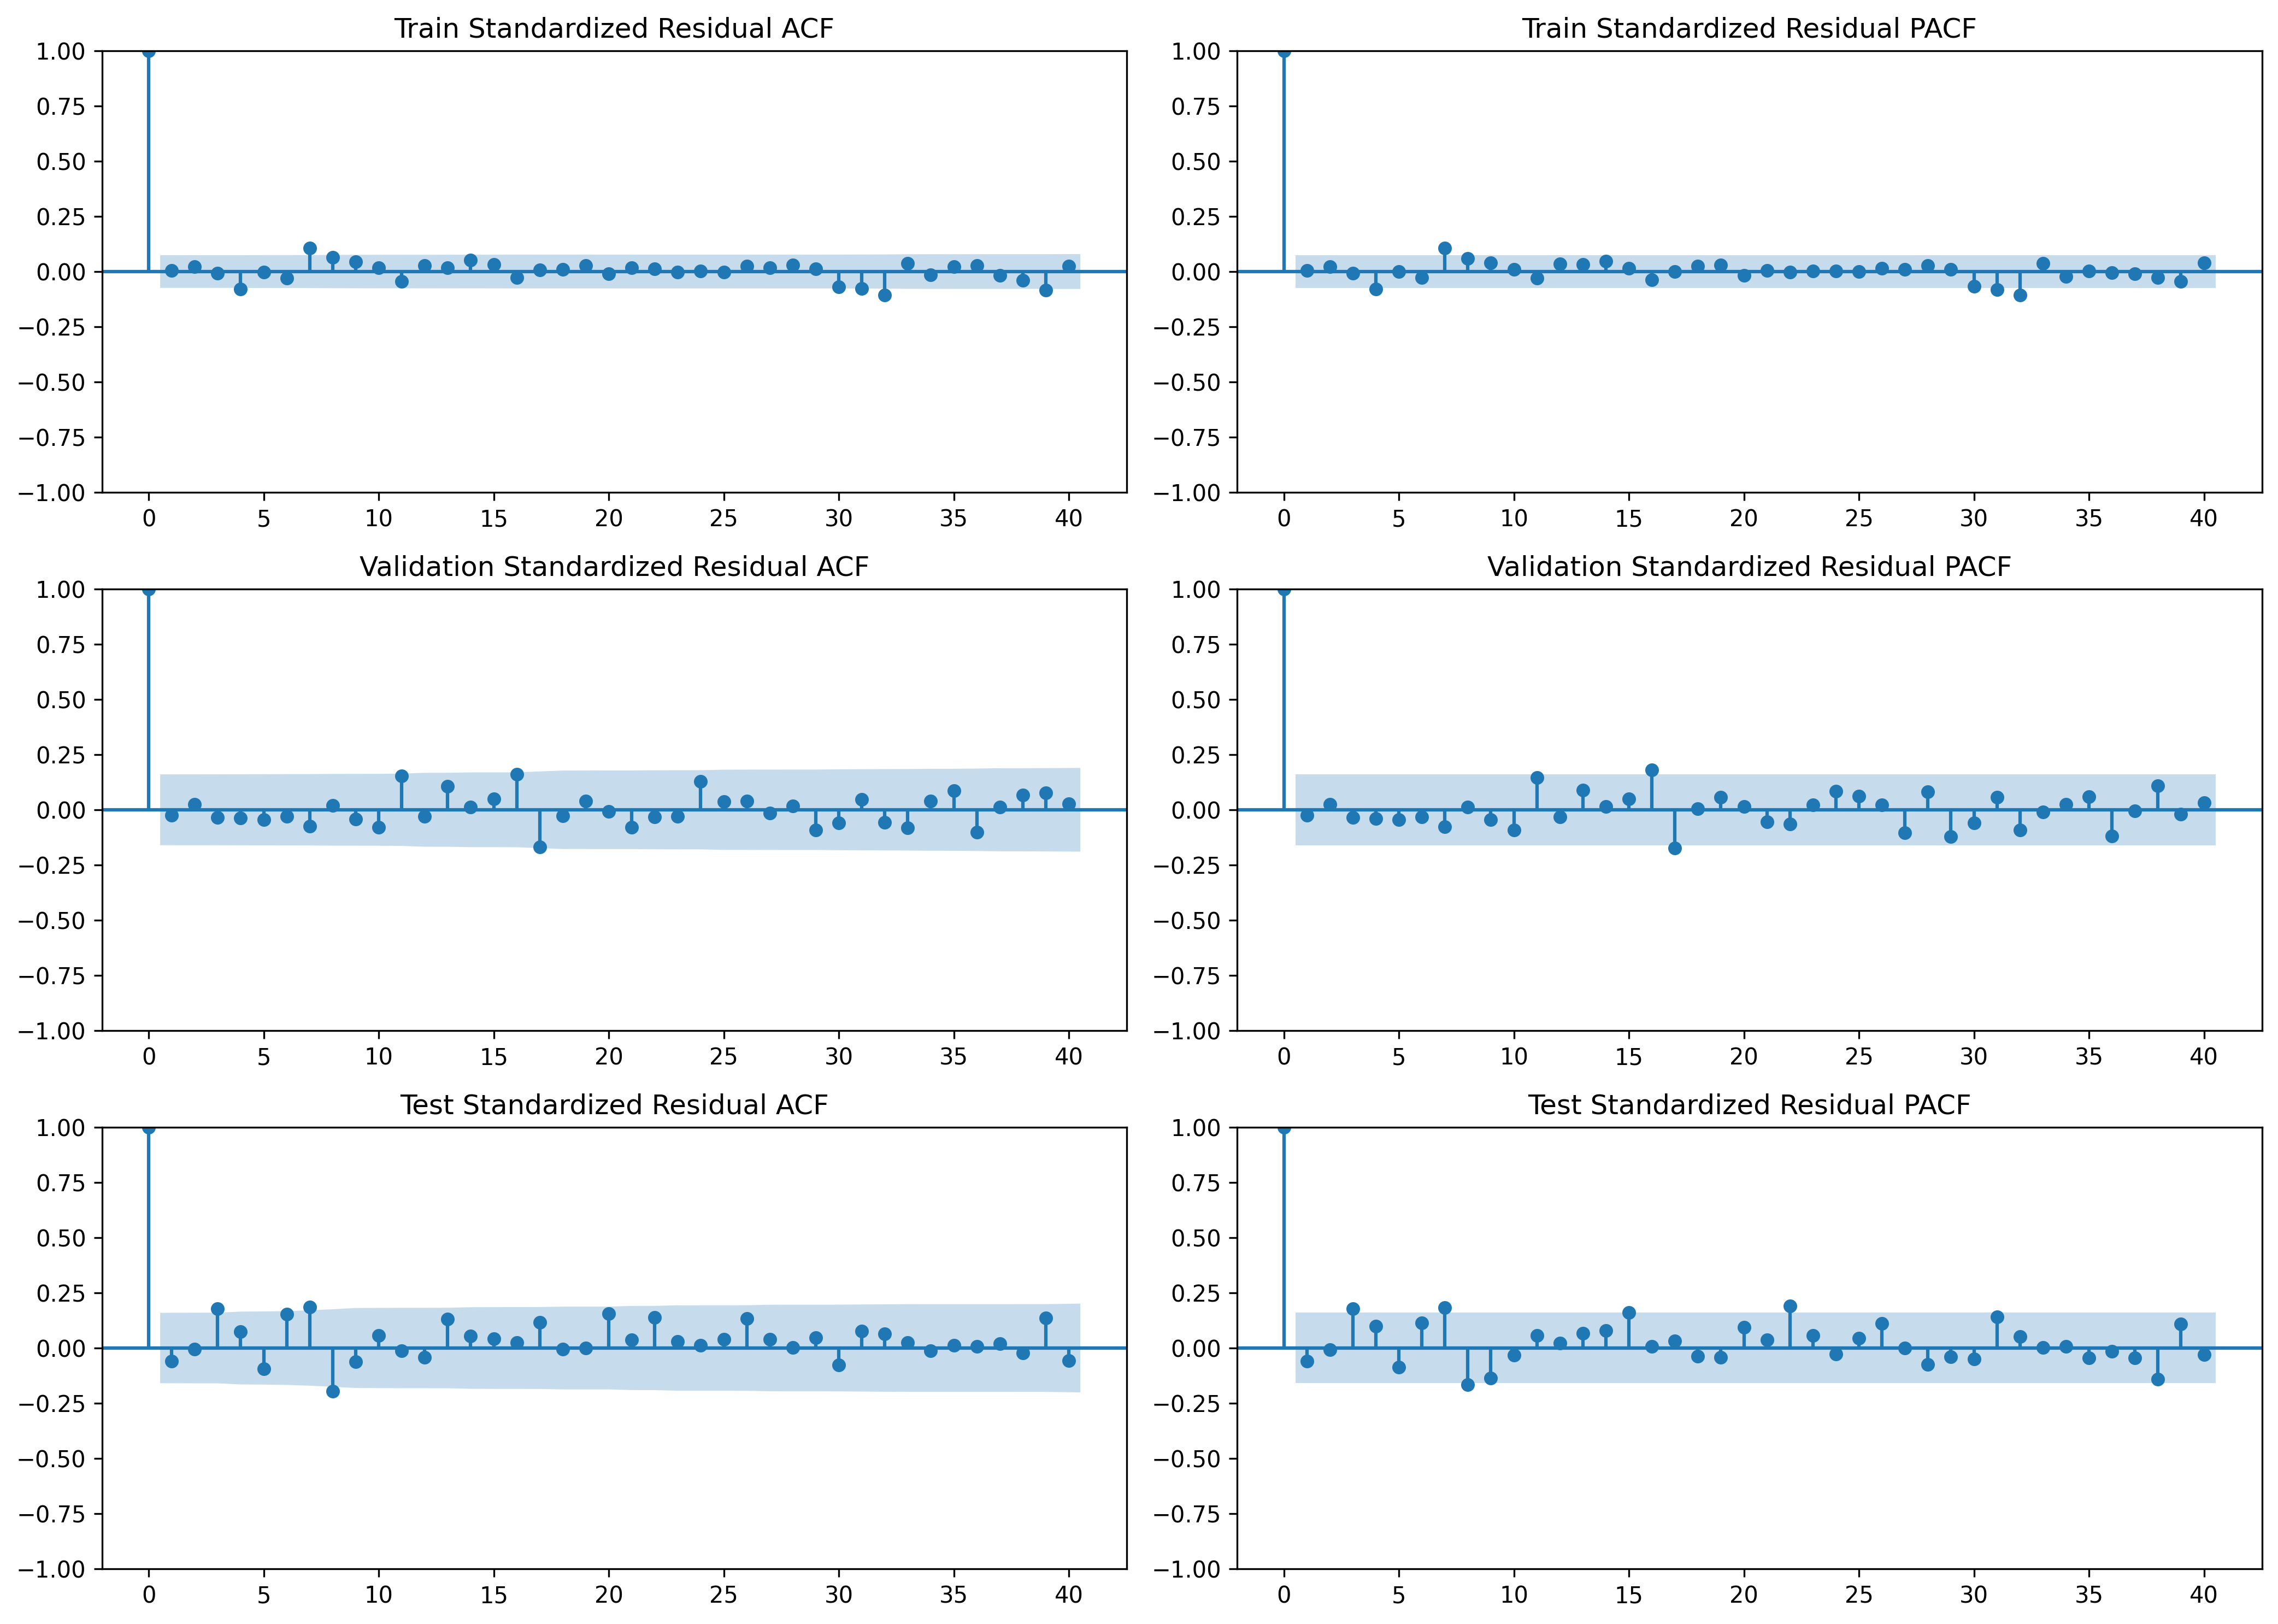


Train Ljung–Box Test on STANDARDIZED Residuals (lag=20)
-----------------------------------------------------------------
LB statistic = 23.9401
p-value      = 0.245

Validation Ljung–Box Test on STANDARDIZED Residuals (lag=20)
-----------------------------------------------------------------
LB statistic = 19.1699
p-value      = 0.5108

Test Ljung–Box Test on STANDARDIZED Residuals (lag=20)
-----------------------------------------------------------------
LB statistic = 35.0119
p-value      = 0.02004


In [144]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# 1. Compute standardized residuals
# ------------------------------------------------------------
# Avoid division by zero
eps = 1e-8

std_res_tr = (ytr_true - ytr_pred_mean) / (ytr_pred_std + eps)
std_res_va = (yva_true - yva_pred_mean) / (yva_pred_std + eps)
std_res_te = (yte_true - yte_pred_mean) / (yte_pred_std + eps)


# ------------------------------------------------------------
# 2. Normality tests on standardized residuals
# ------------------------------------------------------------
def standardized_normality_tests(residuals, name=""):
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    jb_stat, jb_p = stats.jarque_bera(residuals)

    print(f"\n{name} STANDARDIZED Residual Normality Tests")
    print("-" * 55)
    print(f"Shapiro-Wilk:  stat={shapiro_stat:.4f}, p={shapiro_p:.4g}")
    print(f"Jarque-Bera:   stat={jb_stat:.4f}, p={jb_p:.4g}")

standardized_normality_tests(std_res_tr, "Train")
standardized_normality_tests(std_res_va, "Validation")
standardized_normality_tests(std_res_te, "Test")


# ------------------------------------------------------------
# 3. ACF / PACF of standardized residuals
# ------------------------------------------------------------
max_lag = 40

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

plot_acf(std_res_tr, lags=max_lag, ax=axes[0,0])
plot_pacf(std_res_tr, lags=max_lag, ax=axes[0,1], method="ywm")
axes[0,0].set_title("Train Standardized Residual ACF")
axes[0,1].set_title("Train Standardized Residual PACF")

plot_acf(std_res_va, lags=max_lag, ax=axes[1,0])
plot_pacf(std_res_va, lags=max_lag, ax=axes[1,1], method="ywm")
axes[1,0].set_title("Validation Standardized Residual ACF")
axes[1,1].set_title("Validation Standardized Residual PACF")

plot_acf(std_res_te, lags=max_lag, ax=axes[2,0])
plot_pacf(std_res_te, lags=max_lag, ax=axes[2,1], method="ywm")
axes[2,0].set_title("Test Standardized Residual ACF")
axes[2,1].set_title("Test Standardized Residual PACF")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Ljung–Box test on standardized residuals
# ------------------------------------------------------------
def ljung_box_standardized(residuals, name="", lags=20):
    lb = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    stat = lb["lb_stat"].values[0]
    pval = lb["lb_pvalue"].values[0]

    print(f"\n{name} Ljung–Box Test on STANDARDIZED Residuals (lag={lags})")
    print("-" * 65)
    print(f"LB statistic = {stat:.4f}")
    print(f"p-value      = {pval:.4g}")

ljung_box_standardized(std_res_tr, "Train")
ljung_box_standardized(std_res_va, "Validation")
ljung_box_standardized(std_res_te, "Test")
